# Confetti Ceiling Pipeline

Tests the best achievable tracking when confetti is available at **both** segmentation
and tracking time — but all cells are tracked together (not split by population).

**Two improvements over the greyscale baseline:**
1. **Segmentation** (`variance_dropout_p=0.0`): UNet always sees confetti channels →
   better separation of touching cells from different populations
2. **Tracking** (btrack VISUAL update): L2-normalised confetti color attached to each
   detection as a feature; btrack's ILP uses cosine similarity alongside motion

Compare against greyscale baseline: btrack full-pop µm → continuity=0.899, switch_rate=0.246

In [1]:
import os, sys, gc
import numpy as np
import torch
import matplotlib.pyplot as plt

os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
sys.path.insert(0, '/home/dominik/cc-workspace/coastal')
# cecelia IO helpers come from the installed `cecelia` package
# (pip install -e <cecelia-feijoa>/python) — no sys.path / CECELIA_APP needed.

%load_ext autoreload
%autoreload 2

from coastal import (
    filter_small_cells,
    compute_3d_centroids,
    extract_cell_intensities,
    score_tracking,
)
from coastal.train import prepare_data_for_unet_batch_4d, train_with_metrics
from coastal.segment import Inference3D

import cecelia.utils.zarr_utils as zarr_utils
import cecelia.utils.ome_xml_utils as ome_xml_utils
from cecelia.utils.dim_utils import DimUtils

device = ('cuda' if torch.cuda.is_available()
          else 'mps' if torch.backends.mps.is_available()
          else 'cpu')
print(f'Device: {device}')

Device: cuda


In [2]:
BASE_DIR      = '/home/dominik/cecelia/projects/R0YiZv/ANALYSIS'
LABELS_DIR    = '/home/dominik/Downloads/TMP/coastal_labels/'
from importlib.resources import files  # vendored btrack config; wheel- or editable-install-safe
BTRACK_CONFIG = os.environ.get('BTRACK_CONFIG',
    str(files('cecelia').joinpath('tasks', 'tracking', 'cell_config.json')))

# uIDs        = ['xh9GFi', 'N0VlpP', 'qcN9Br', 'ENH3fS', 'uNTqPu']
# uIDs        = ['xh9GFi']
uIDs = [
    'QS0Z6B', 'E25ivV', 'LlBxY9', 'iRxilR', '2CHUML',
    'BVnKB3', 'ELoL5a', 'fFnZOv', 'CdQYH0', 'hfMMQ1',
    'IRaTvy', 'rK8nQY', 'AksHak', '4D4QUc', 'B1OSJo',
    'mI9UUN'
]
# Channels [1,2,3] for QS0Z6B→CdQYH0; [0,2,3] for hfMMQ1→mI9UUN
CH_INDICES_MAP = {
    **{uid: [1, 2, 3] for uid in ['QS0Z6B', 'E25ivV', 'LlBxY9', 'iRxilR', '2CHUML',
                                    'BVnKB3', 'ELoL5a', 'fFnZOv', 'CdQYH0']},
    **{uid: [0, 2, 3] for uid in ['hfMMQ1', 'IRaTvy', 'rK8nQY', 'AksHak', '4D4QUc',
                                    'B1OSJo', 'mI9UUN']},
}
COLOR_NAMES = ['Red', 'Green', 'Blue']
MIN_VOXELS  = 200
TARGET_SIZE = (384, 384)

BEST_PARAMS = {
    'seed_size': 12,
    'embedding_blur_sigma': 1.0,
    'prob_threshold': 0.4,
    'min_component_size': 12,
    'max_iter': 200,
    'min_boundary_pixels': 8,
    'affinity_threshold': 0.5534,
    'merge_affinity_threshold': 0.2261,
    'merge_max_distance': 0.6198,
    'merge_contact_brightness_threshold': 0.3733,
    'prob_weight': 0.3366,
}

## 1. Load volumes

In [3]:
volumes = {}
pix_res = {}

for uid in uIDs:
    # im_path = os.path.join(BASE_DIR, f'0/{uid}/ccidCorrected.zarr')
    im_path = os.path.join(BASE_DIR, f'0/{uid}/ccidDriftCorrected.zarr')
    im, _   = zarr_utils.open_as_zarr(im_path, as_dask=True)
    omexml  = ome_xml_utils.parse_meta(im_path)
    du      = DimUtils(omexml, use_channel_axis=True)
    du.calc_image_dimensions(im[0].shape)
    volumes[uid] = im
    pix_res[uid] = du.im_physical_sizes()

for uid in uIDs:
    T, C, Z, H, W = np.array(volumes[uid][0]).shape
    print(f'{uid}: T={T} C={C} Z={Z} H={H} W={W}  pix_res={pix_res[uid]}')

<zarr.hierarchy.Group '/' read-only>
[180, 4, 10, 540, 516]
[516, 540, 10, 4, 180]
['X', 'Y', 'Z', 'C', 'T']
<zarr.hierarchy.Group '/' read-only>
[180, 4, 12, 538, 564]
[564, 538, 12, 4, 180]
['X', 'Y', 'Z', 'C', 'T']
<zarr.hierarchy.Group '/' read-only>
[180, 4, 11, 526, 550]
[550, 526, 11, 4, 180]
['X', 'Y', 'Z', 'C', 'T']
<zarr.hierarchy.Group '/' read-only>
[180, 4, 11, 560, 528]
[528, 560, 11, 4, 180]
['X', 'Y', 'Z', 'C', 'T']
<zarr.hierarchy.Group '/' read-only>
[180, 4, 10, 539, 526]
[526, 539, 10, 4, 180]
['X', 'Y', 'Z', 'C', 'T']
<zarr.hierarchy.Group '/' read-only>
[180, 4, 13, 542, 550]
[550, 542, 13, 4, 180]
['X', 'Y', 'Z', 'C', 'T']
<zarr.hierarchy.Group '/' read-only>
[180, 4, 10, 530, 534]
[534, 530, 10, 4, 180]
['X', 'Y', 'Z', 'C', 'T']
<zarr.hierarchy.Group '/' read-only>
[180, 4, 15, 531, 586]
[586, 531, 15, 4, 180]
['X', 'Y', 'Z', 'C', 'T']
<zarr.hierarchy.Group '/' read-only>
[180, 4, 13, 525, 568]
[568, 525, 13, 4, 180]
['X', 'Y', 'Z', 'C', 'T']
<zarr.hierarchy.Gro

## 2. Train UNet — `variance_dropout_p=0.5`

Train with confetti channels as variance metrics but randomly drop them 50% of the time.
The model learns to segment on optical flow structure alone; confetti is a bonus signal.
At inference time, run with `ch_indices=None` (grayscale only).

In [4]:
all_frames, all_temporal, all_variance, all_frames_multi = prepare_data_for_unet_batch_4d(
    volumes,
    n_sequences=3,
    seq_len=20,
    ch_indices=CH_INDICES_MAP[uIDs[0]],  # fixed set for training (flow metrics only)
    temporal_scales=[1, 2, 4],
    cumulative_window=2,
    random_seed=42,
    target_size=TARGET_SIZE,
)

TRAIN_RATIO = 0.8
train_frames_l, train_temporal, train_variance = [], [], []
test_frames_l,  test_temporal,  test_variance  = [], [], []

for frames, temporal, variance in zip(all_frames, all_temporal, all_variance):
    n_train = int(len(frames) * TRAIN_RATIO)
    train_frames_l.append(frames[:n_train]);  test_frames_l.append(frames[n_train:])
    train_temporal.extend(temporal[:n_train]); test_temporal.extend(temporal[n_train:])
    train_variance.extend(variance[:n_train]); test_variance.extend(variance[n_train:])

train_frames = np.concatenate(train_frames_l, axis=0)
test_frames  = np.concatenate(test_frames_l,  axis=0)
print(f'Train: {train_frames.shape}  Test: {test_frames.shape}  '
      f'variance metrics/frame: {len(train_variance[0])}')
      
torch.cuda.empty_cache()



4D BATCH PREPARATION
  16 volumes × 3 sequences × 20 frames = 48 sequences

Volume 1/16: shape (180, 4, 10, 540, 516)


Frame metrics: 100%|████████████████████████████| 20/20 [00:00<00:00, 24.87it/s]


  Seq 1/3: z=0, t=14–33 | 14 temporal + 3 variance metrics


Frame metrics: 100%|████████████████████████████| 20/20 [00:00<00:00, 30.53it/s]


  Seq 2/3: z=4, t=124–143 | 14 temporal + 3 variance metrics


...

  Seq 1/3: z=0, t=10–29 | 14 temporal + 3 variance metrics


Frame metrics: 100%|████████████████████████████| 20/20 [00:00<00:00, 24.20it/s]


  Seq 2/3: z=7, t=110–129 | 14 temporal + 3 variance metrics


Frame metrics: 100%|████████████████████████████| 20/20 [00:00<00:00, 26.87it/s]


  Seq 3/3: z=14, t=131–150 | 14 temporal + 3 variance metrics

✓ 48 sequences ready for train_test_split_per_movie

Train: (768, 384, 384)  Test: (192, 384, 384)  variance metrics/frame: 3


In [5]:
# Pick one sequence for visual inspection before training
EVAL_SEQ_IDX    = 0
eval_frames_maxproj = all_frames[EVAL_SEQ_IDX]        # [seq_len, H, W]
eval_temporal       = all_temporal[EVAL_SEQ_IDX]      # list of dicts
eval_variance       = all_variance[EVAL_SEQ_IDX]      # list of dicts
eval_frames_multi   = all_frames_multi[EVAL_SEQ_IDX]  # [seq_len, C, H, W]
eval_ch_indices     = CH_INDICES_MAP[uIDs[0]]         # channels used for this sequence

print(f'Eval sequence {EVAL_SEQ_IDX}: {eval_frames_maxproj.shape} frames, '
      f'{len(eval_temporal[0])} temporal metrics, '
      f'{len(eval_variance[0])} variance metrics')


Eval sequence 0: (20, 384, 384) frames, 14 temporal metrics, 3 variance metrics


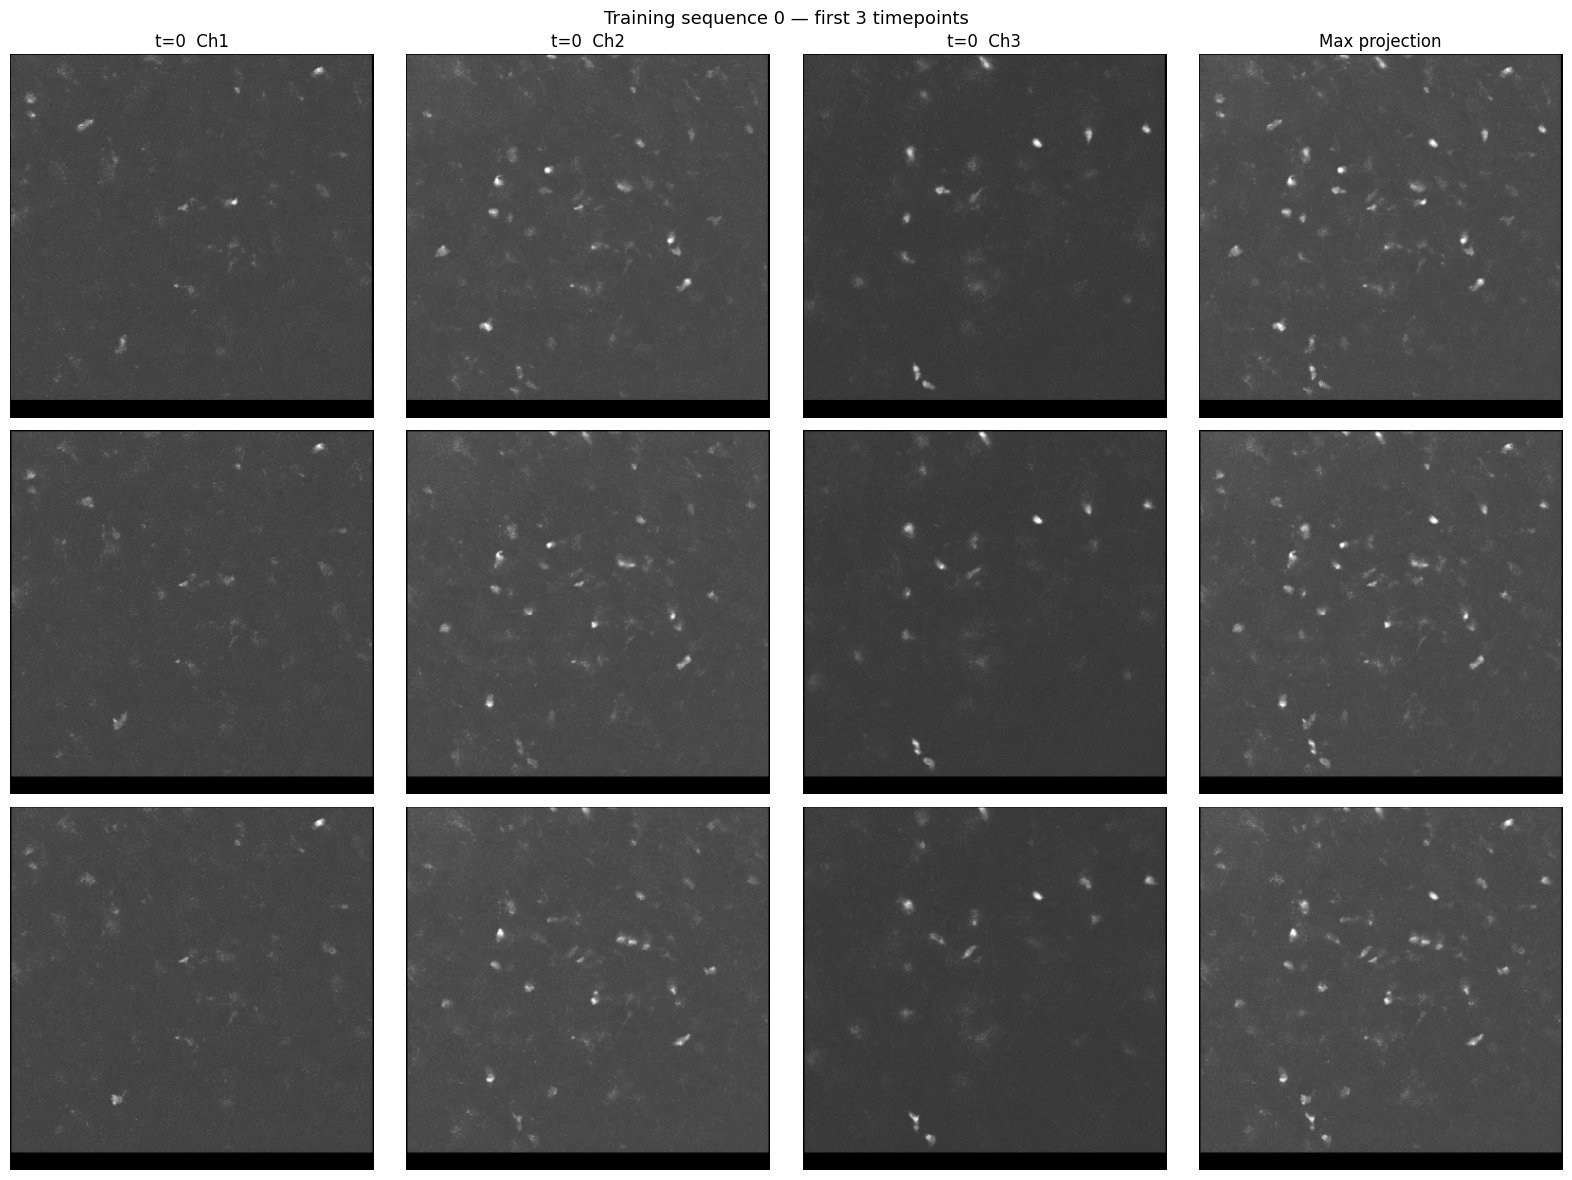

In [6]:
# Raw channels + max projection
n_ch = eval_frames_multi.shape[1]
n_t  = 3

fig, axes = plt.subplots(n_t, n_ch + 1, figsize=(4 * (n_ch + 1), 4 * n_t))
for t in range(n_t):
    for ci in range(n_ch):
        axes[t, ci].imshow(eval_frames_multi[t, ci], cmap='gray')
        axes[t, ci].set_title(f't={t}  Ch{eval_ch_indices[ci]}' if t == 0 else '')
        axes[t, ci].axis('off')
    axes[t, n_ch].imshow(eval_frames_maxproj[t], cmap='gray')
    axes[t, n_ch].set_title('Max projection' if t == 0 else '')
    axes[t, n_ch].axis('off')

plt.suptitle(f'Training sequence {EVAL_SEQ_IDX} — first {n_t} timepoints', fontsize=13)
plt.tight_layout()
plt.show()


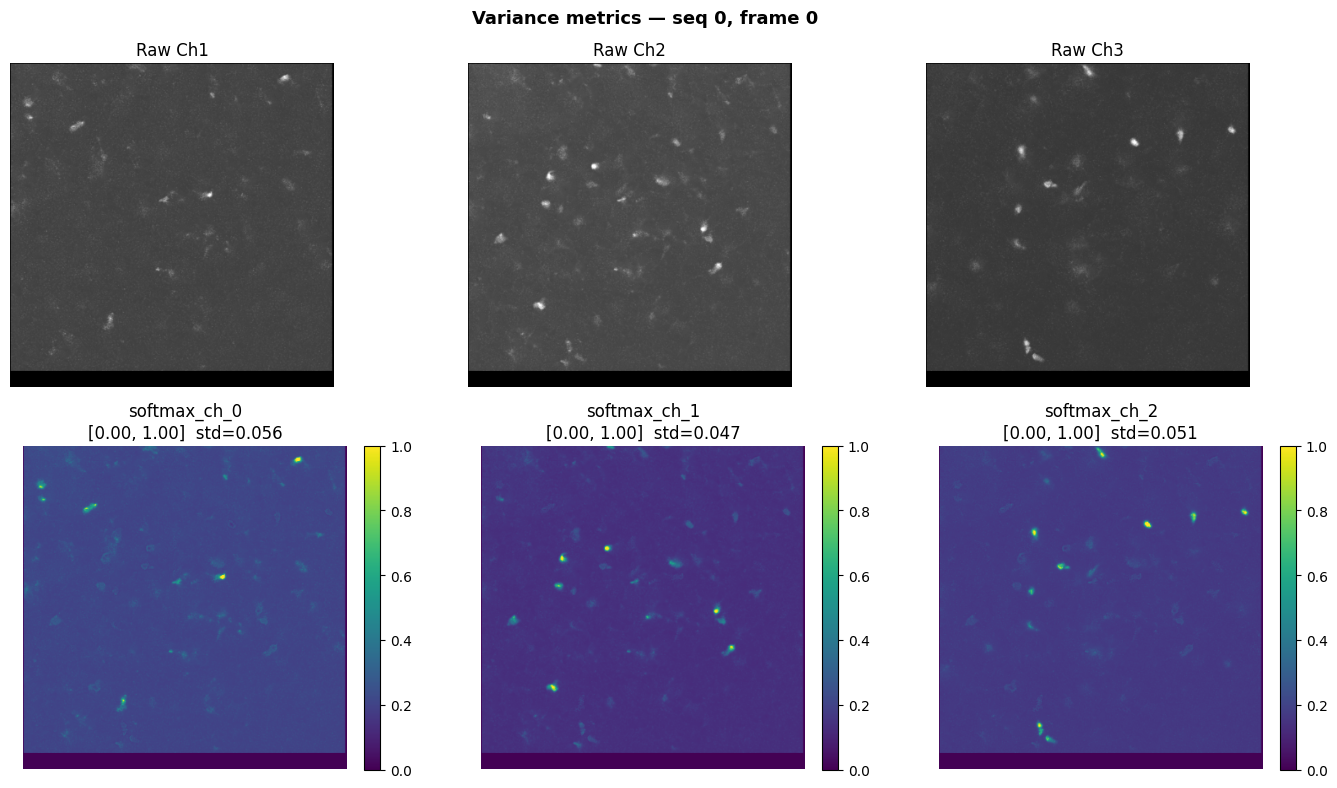

In [7]:
# Variance metrics for one frame
frame_idx = 0
var_dict  = eval_variance[frame_idx]
var_keys  = sorted(var_dict.keys())
n_ch      = eval_frames_multi.shape[1]
n_cols    = 3
n_rows    = 1 + (len(var_keys) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()

for ci in range(n_ch):
    axes[ci].imshow(eval_frames_multi[frame_idx, ci], cmap='gray')
    axes[ci].set_title(f'Raw Ch{eval_ch_indices[ci]}')
    axes[ci].axis('off')

for i, key in enumerate(var_keys):
    ax  = axes[n_cols + i]
    arr = var_dict[key]
    im  = ax.imshow(arr, cmap='viridis', vmin=0, vmax=1)
    ax.set_title(f'{key}\n[{arr.min():.2f}, {arr.max():.2f}]  std={arr.std():.3f}')
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

for j in range(n_cols + len(var_keys), len(axes)):
    axes[j].axis('off')

plt.suptitle(f'Variance metrics — seq {EVAL_SEQ_IDX}, frame {frame_idx}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


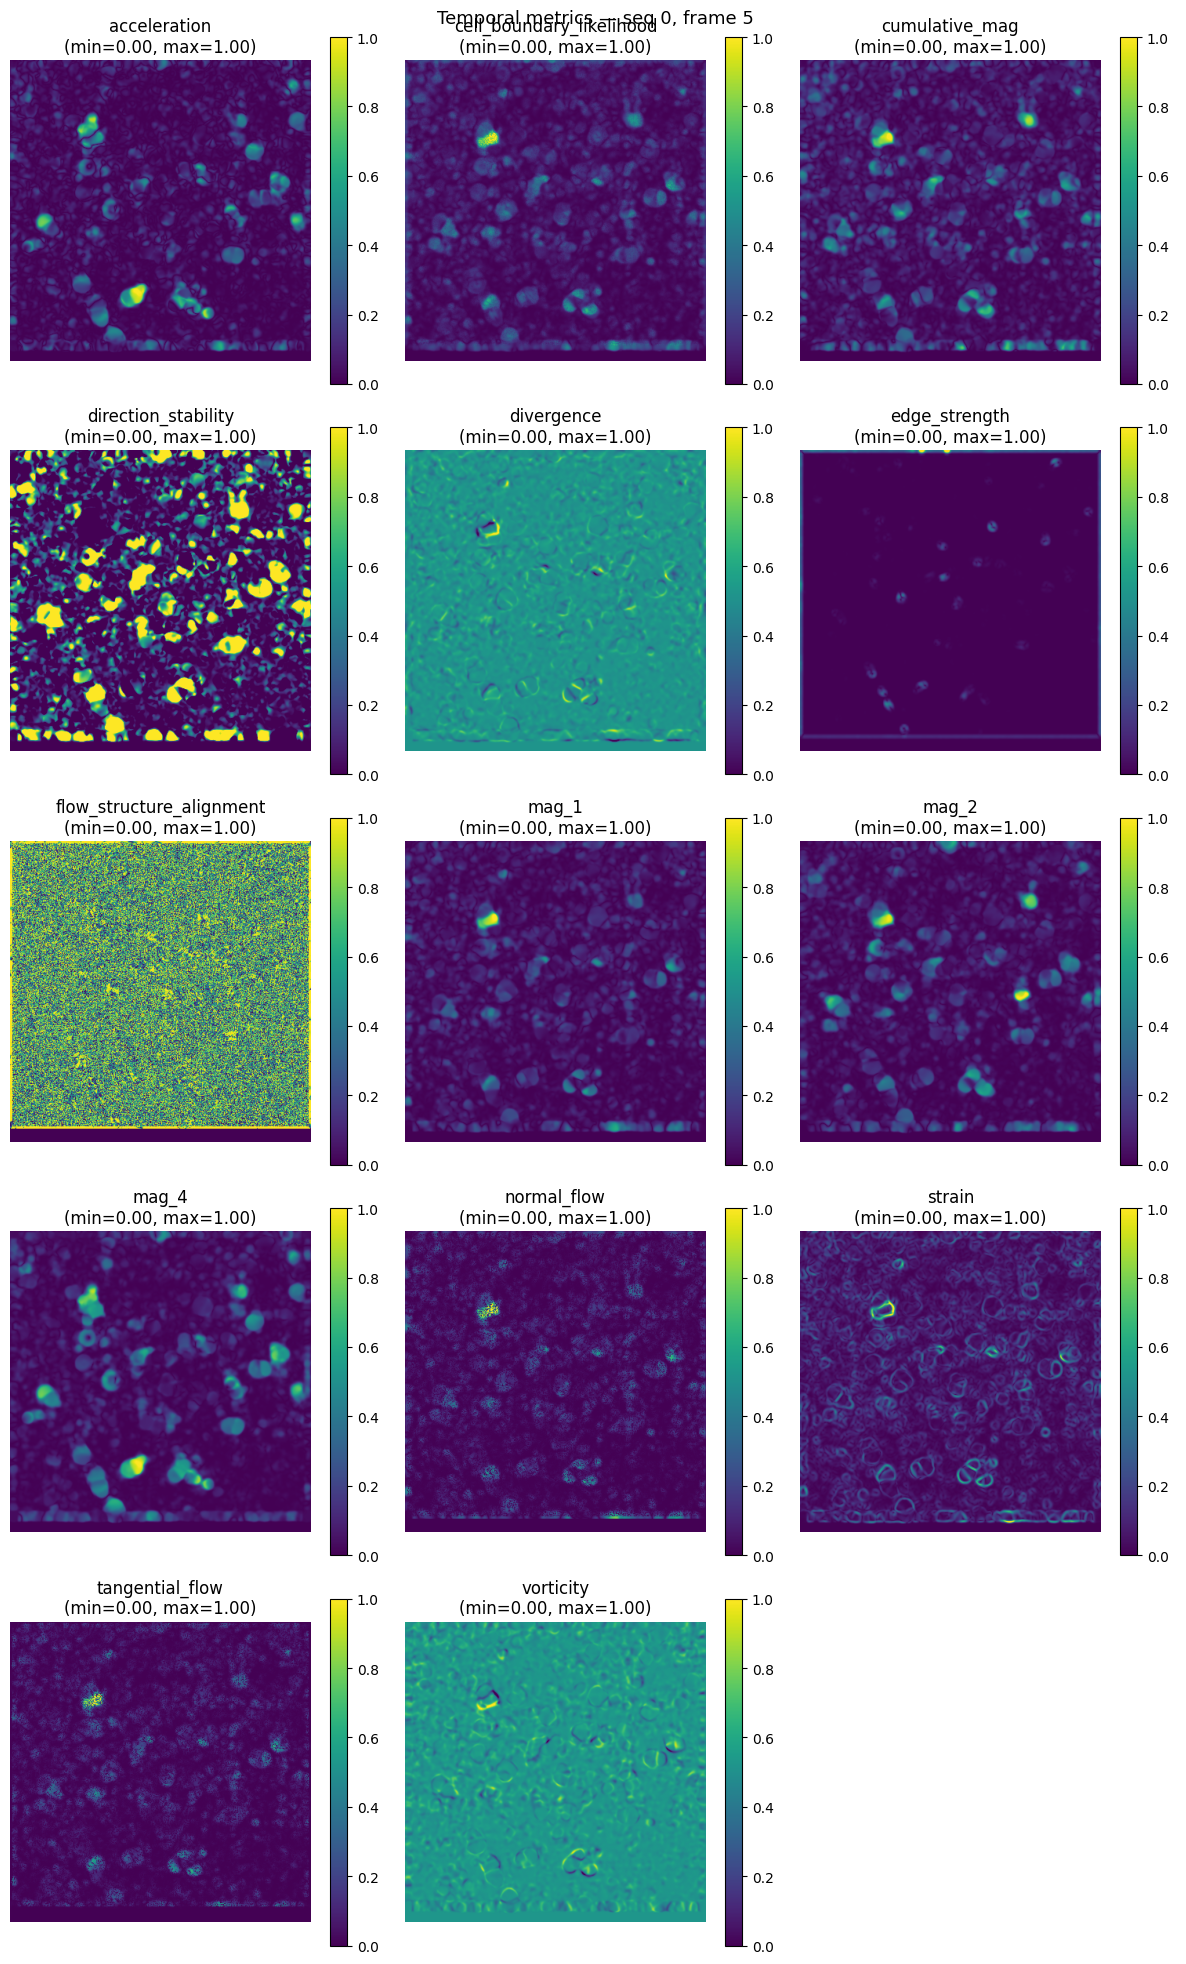

In [8]:
# Temporal (optical flow) metrics for one frame
frame_idx    = 5
metrics_dict = eval_temporal[frame_idx]

valid_metrics = [
    (name, metrics_dict[name])
    for name in sorted(metrics_dict.keys())
    if isinstance(metrics_dict[name], np.ndarray) and metrics_dict[name].ndim == 2
]

cols = 3
rows = (len(valid_metrics) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))
axes = axes.flatten()

for idx, (name, arr) in enumerate(valid_metrics):
    im = axes[idx].imshow(arr, cmap='viridis')
    axes[idx].set_title(f'{name}\n(min={arr.min():.2f}, max={arr.max():.2f})')
    axes[idx].axis('off')
    plt.colorbar(im, ax=axes[idx])

for idx in range(len(valid_metrics), len(axes)):
    axes[idx].axis('off')

plt.suptitle(f'Temporal metrics — seq {EVAL_SEQ_IDX}, frame {frame_idx}', fontsize=13)
plt.tight_layout()
plt.show()


In [11]:
NUM_EPOCHS = 80


TRAINING: INTENSITY + TEMPORAL + VARIANCE (3-LOSS)
Loss: Intensity (1.0) + Temporal (1.0) + Variance (1.0, window=32px, dropout_p=0.5) + Warp (0.0)
Gradient clipping: 1.0 | AMP: True | Workers: 4

Model params: 1,804,417
Input channels: 1 (frame) + 14 (temporal) + 3 (variance, p_drop=0.5) = 18
Embedding dimension: 64
Dataset size: 768 frames

Epoch   1/80: total=2.7327 | int=0.5726 | tmp=1.1027 | var=1.0573
  Center 1: 2 frames, cumulative mag: min=0.000000, max=22.658508
  Center 1: 2 frames, cumulative mag: min=0.000000, max=0.000000
  Center 1: 2 frames, cumulative mag: min=0.000000, max=15.004988
  Center 1: 2 frames, cumulative mag: min=0.000000, max=0.000000
  Center 1: 2 frames, cumulative mag: min=0.000000, max=0.000000
  Center 1: 2 frames, cumulative mag: min=0.000000, max=0.000000
  Center 1: 2 frames, cumulative mag: min=0.000000, max=0.000000
  Center 0: 1 frames, cumulative mag: min=0.000000, max=0.000000
  Center 2: 2 frames, cumulative mag: min=0.000000, max=0.000000
 

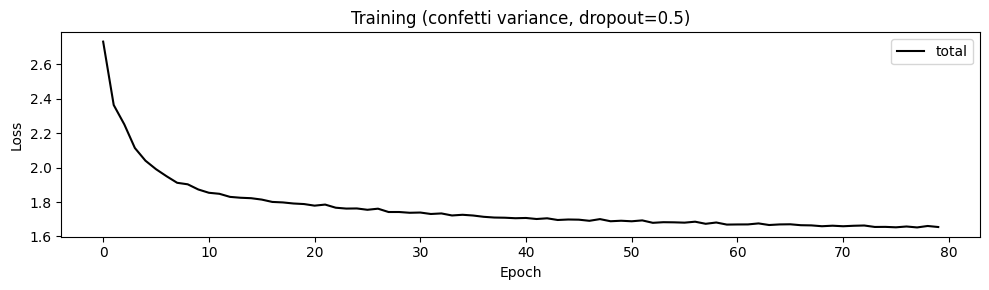

In [9]:

model, history = train_with_metrics(
    train_frames,
    train_temporal,
    variance_metrics_norm=train_variance,
    num_epochs=NUM_EPOCHS,
    batch_size=4,
    embedding_dim=64,
    intensity_weight=1.0,
    temporal_weight=1.0,
    variance_weight=1.0,
    variance_window_size=32,
    variance_dropout_p=0.5,   # ← only change from optical_flow.ipynb
    device=device,
)

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(history['total'], 'k-', label='total')
ax.set(xlabel='Epoch', ylabel='Loss', title='Training (confetti variance, dropout=0.5)')
ax.legend(); plt.tight_layout(); plt.show()

In [12]:
from coastal import save_model, load_model

# save_model(
#     model,
#     path="/home/dominik/Downloads/TMP/coastal_model.pt",
#     metadata={"num_epochs": NUM_EPOCHS, "target_size": TARGET_SIZE},
# )

# To reload later:
model = load_model("/home/dominik/Downloads/TMP/coastal_model.pt", device="cuda")

Model saved to /home/dominik/Downloads/TMP/coastal_model.pt


## 3. Inference3D — all cells together

In [ ]:
inferencer_3d = Inference3D(model=model, device=device, **BEST_PARAMS)

coastal_instances_per_uid = {}
for uid, vol in volumes[:1].items():
    inst, _ = inferencer_3d.predict_temporal_volume(
        np.asarray(vol[0]),
        ch_indices=CH_INDICES_MAP[uid],
        stitch_threshold=0.1,
        gap_tolerance=1,
        gap_iou_threshold=0.3,
        n_workers=8,
    )
    coastal_instances_per_uid[uid] = filter_small_cells(inst, min_voxels=MIN_VOXELS)
    n = np.mean([len(np.unique(coastal_instances_per_uid[uid][t]))-1
                 for t in range(inst.shape[0])])
    print(f'{uid}: {n:.0f} cells/frame')


In [6]:
LABELS_DIR = '/home/dominik/Downloads/TMP/coastal_labels'
os.makedirs(LABELS_DIR, exist_ok=True)

In [7]:
import os

# Save coastal instances (run once after §3 Inference3D completes)
for uid, inst in coastal_instances_per_uid.items():
    np.save(os.path.join(LABELS_DIR, f'{uid}_instances_4d.npy'), inst)
    print(f'Saved {uid}: {inst.shape}')

# Load coastal instances from disk (skip §3 Inference3D on subsequent runs)
# coastal_instances_per_uid = {}
# for uid in uIDs:
#     path = os.path.join(LABELS_DIR, f'{uid}_instances_4d.npy')
#     inst = np.load(path)
#     f    = filter_small_cells(inst, min_voxels=MIN_VOXELS)
#     removed   = [len(np.unique(inst[t])) - 1 - (len(np.unique(f[t])) - 1) for t in range(inst.shape[0])]
#     remaining = [len(np.unique(f[t])) - 1 for t in range(f.shape[0])]
#     print(f'{uid}:  removed mean={np.mean(removed):.1f}/frame  remaining mean={np.mean(remaining):.0f}/frame')
#     coastal_instances_per_uid[uid] = f


xh9GFi:  removed mean=0.0/frame  remaining mean=360/frame


## 4. Feature extraction

In [8]:
# Per-cell confetti intensity — used by score_tracking for ground-truth evaluation
c_intensities_per_uid = {}
scale_um_per_uid      = {}

for uid in uIDs:
    vol = np.asarray(volumes[uid][0])
    pr  = pix_res[uid]
    scale_um_per_uid[uid] = np.array([pr['z'], pr['y'], pr['x']], dtype=np.float32)

    inst = coastal_instances_per_uid[uid]
    c_intensities_per_uid[uid] = extract_cell_intensities(inst, vol, CH_INDICES_MAP[uid])

    n = np.mean([len(np.unique(inst[t])) - 1 for t in range(inst.shape[0])])
    print(f'{uid}: {n:.0f} cells/frame')


xh9GFi: confetti 360  coastal 790 cells/frame


## 5. Baseline — `track_sequence` on coastal instances

Kalman + Hungarian LAP. Two conditions:
- `w_color=0`: pure motion (honest Kalman baseline, no confetti)
- `w_color=1`: + confetti cosine cost (current best honest result)

**Target for ABM to beat:** continuity=0.848, switch_rate=0.214 (w_color=1.0)

In [ ]:
# Autocorrelation check on existing tracks
from coastal.track import compute_3d_centroids

lag1_errors, lag2_errors = [], []
nbr_cosines = []

for uid in uIDs:
    pr    = pix_res[uid]
    scale = scale_um_per_uid[uid]
    tracks = tracks_coastal_c_per_uid[uid]

    for tid, tpoints in tracks.items():
        ts = sorted(tpoints.keys())
        if len(ts) < 4:
            continue
        vels = [tpoints[ts[i+1]] - tpoints[ts[i]] for i in range(len(ts)-1)]
        for i in range(1, len(vels)-1):
            pred_lag1 = vels[i]
            pred_lag2 = 2*vels[i] - vels[i-1]   # linear extrapolation
            true_v    = vels[i+1]
            lag1_errors.append(np.linalg.norm(true_v - pred_lag1))
            lag2_errors.append(np.linalg.norm(true_v - pred_lag2))

    # Neighbour cosine similarity
    inst = coastal_instances_per_uid[uid]
    centroids_all = compute_3d_centroids(inst)
    vel_map = {}  # (uid, t, cid) -> vel
    for tid, tpoints in tracks.items():
        ts = sorted(tpoints.keys())
        for i in range(len(ts)-1):
            vel_map[(ts[i], tid)] = tpoints[ts[i+1]] - tpoints[ts[i]]

    for t in range(inst.shape[0]-1):
        items = [(tid, vel_map[(t, tid)]) for tid in tracks
                 if (t, tid) in vel_map and t in tracks[tid]]
        if len(items) < 2:
            continue
        positions = np.array([tracks[tid][t] for tid, _ in items])
        vels_t    = np.array([v for _, v in items])
        for i in range(len(items)):
            dists = np.linalg.norm(positions - positions[i], axis=1)
            nbrs  = np.where((dists > 0) & (dists < 25.0))[0]
            for j in nbrs:
                n0 = np.linalg.norm(vels_t[i]); n1 = np.linalg.norm(vels_t[j])
                if n0 > 1e-6 and n1 > 1e-6:
                    nbr_cosines.append(np.dot(vels_t[i], vels_t[j]) / (n0*n1))

print(f"Lag-1 MAE: {np.mean(lag1_errors):.3f} µm/frame")
print(f"Lag-2 MAE: {np.mean(lag2_errors):.3f} µm/frame")
print(f"Lag-2 improvement: {(np.mean(lag1_errors)-np.mean(lag2_errors))/np.mean(lag1_errors)*100:.1f}%")
print(f"Neighbour cosine similarity (mean): {np.mean(nbr_cosines):.3f}  (n={len(nbr_cosines)})")

In [13]:
from coastal.abm import track_sequence

W_COLOR_TRACK = [0.0]   # grayscale tracking — confetti used only for scoring

coastal_c_results        = {w: {} for w in W_COLOR_TRACK}
tracks_coastal_c_per_uid = {}

for uid in uIDs:
    pr     = pix_res[uid]
    inst   = coastal_instances_per_uid[uid]
    intens = c_intensities_per_uid[uid]
    vol    = np.asarray(volumes[uid][0])
    print(f'\n=== {uid} ===')

    for w in W_COLOR_TRACK:
        tracks = track_sequence(
            instances_4d=inst,
            pix_res=pr,
            w_color=w,
            cell_intensities=intens,
            chi2_gate=9.21,
            max_gap=1,
            max_cost=1.5,
        )
        sc = score_tracking(tracks, inst, vol,
                            ch_indices=CH_INDICES_MAP[uid], pix_res=pr, verbose=False)
        coastal_c_results[w][uid] = sc
        print(f'  w_color={w:.1f}: cont={sc["continuity"]["mean"]:.3f}  '
              f'sr={sc["color_switch_rate"]:.3f}')

        if w == 1.0:
            tracks_coastal_c_per_uid[uid] = tracks

    gc.collect()

print('\n--- track_sequence baseline (mean over movies) ---')
print(f'{"w_color":>8}  {"continuity":>10}  {"switch_rate":>11}')
for w in W_COLOR_TRACK:
    conts = [coastal_c_results[w][uid]['continuity']['mean'] for uid in uIDs]
    srs   = [coastal_c_results[w][uid]['color_switch_rate']  for uid in uIDs]
    print(f'{w:>8.1f}  {np.mean(conts):>10.3f}  {np.mean(srs):>11.3f}')


=== xh9GFi ===
track_sequence: 3239 tracks over 61 frames
Color assignment: 4817 dim cells excluded (dim_quantile=0.1, threshold=9.2034)
  w_color=0.0: cont=0.838  sr=0.263
track_sequence: 3313 tracks over 61 frames
Color assignment: 4817 dim cells excluded (dim_quantile=0.1, threshold=9.2034)
  w_color=1.0: cont=0.838  sr=0.232

--- track_sequence baseline (mean over movies) ---
 w_color  continuity  switch_rate
     0.0       0.838        0.263
     1.0       0.838        0.232


track_sequence: 3313 tracks over 61 frames
=== Transition summary ===
  Total labelled transitions:         30004
  Has alternatives (finite margin):   25836  (86.1%)
  No alternatives (margin = inf):      4168  (13.9%)
  Switches in finite-margin group:     4691  (18.2%)
  Switch rate when margin = inf:     0.061  (no alt → more or less switches?)

=== Margin statistics ===
  median margin (all):               0.1202
  median margin (correct):           0.1758
  median margin (switch):            -0.1660
  mean  margin (correct):            0.2055
  mean  margin (switch):             -0.2077

=== Switch rate per margin decile (0 = least confident) ===
  decile        margin range       n  switches  switch_rate
       0  [-1.4169 – -0.4232]    2584      1406        0.544 <-- enriched
       1  [-0.4231 – -0.1917]    2584       807        0.312 <-- enriched
       2  [-0.1916 – -0.0568]    2583       629        0.244
       3  [-0.0567 – 0.0341]    2584       448        0.173
       4  

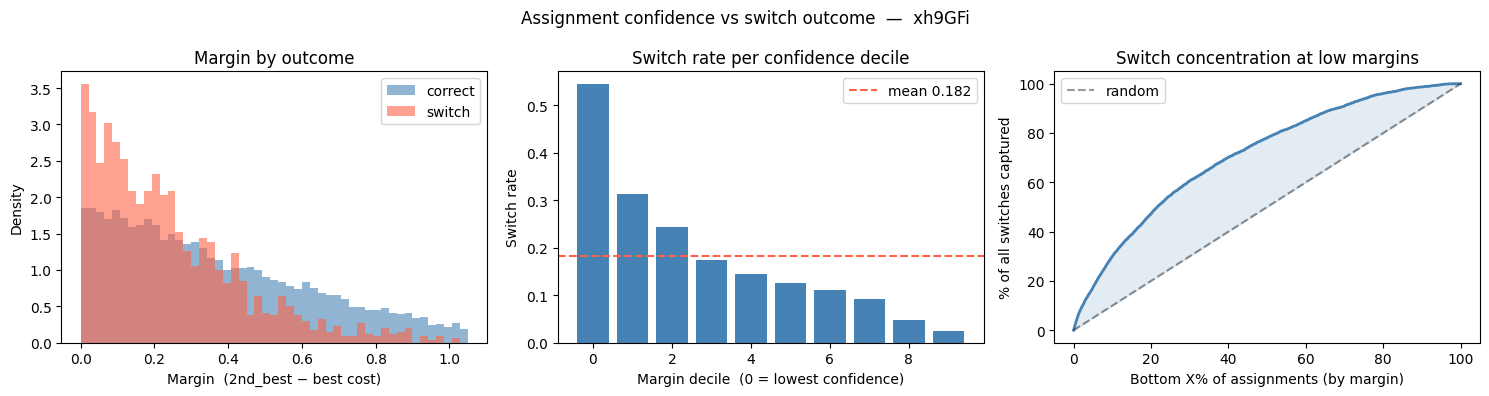

In [10]:
# §5b. Assignment confidence diagnostic
# ─────────────────────────────────────────────────────────────────────────────
# Margin = second_best_cost − best_cost per assignment.
# High margin → confident.  Low margin → two nearly-tied candidates.
# Key question: do low-margin assignments predict confetti switches?

import pandas as pd
from coastal.abm import track_sequence

DIAG_UID = uIDs[0]
pr       = pix_res[DIAG_UID]
inst     = coastal_instances_per_uid[DIAG_UID]
intens   = c_intensities_per_uid[DIAG_UID]

tracks_diag, margins_diag = track_sequence(
    instances_4d=inst, pix_res=pr,
    w_color=1.0, cell_intensities=intens,
    chi2_gate=9.21, max_gap=1, max_cost=1.5,
    return_margins=True,
)

# Dim-cell threshold: 10th percentile of all per-cell max channel values
all_max = [float(np.max(v)) for td in intens.values() for v in td.values()]
dim_thr = float(np.quantile(all_max, 0.10))

def dominant_color(cid, t):
    iv = intens.get(t, {}).get(cid)
    if iv is None or np.max(iv) <= dim_thr:
        return -1
    return int(np.argmax(iv))

# Label each tracked assignment as switch (color changed vs previous frame) or not
rows = []
for (t, tid), (margin, cid) in margins_diag.items():
    color_t = dominant_color(cid, t)
    prev    = margins_diag.get((t - 1, tid))
    if prev is None or color_t < 0:
        continue
    color_prev = dominant_color(prev[1], t - 1)
    if color_prev < 0:
        continue
    rows.append({
        'margin':     float(min(margin, 5.0)),
        'margin_raw': margin,
        'is_switch':  int(color_t != color_prev),
    })

df     = pd.DataFrame(rows)
df_fin = df[df['margin_raw'] < np.inf].copy()
n_inf  = int((df['margin_raw'] == np.inf).sum())
n_sw   = int(df_fin['is_switch'].sum())
mean_sr = df_fin['is_switch'].mean()

print('=== Transition summary ===')
print(f'  Total labelled transitions:        {len(df):>6}')
print(f'  Has alternatives (finite margin):  {len(df_fin):>6}  ({100*len(df_fin)/len(df):.1f}%)')
print(f'  No alternatives (margin = inf):    {n_inf:>6}  ({100*n_inf/len(df):.1f}%)')
print(f'  Switches in finite-margin group:   {n_sw:>6}  ({100*mean_sr:.1f}%)')
inf_sr = df.loc[df['margin_raw'] == np.inf, 'is_switch'].mean()
print(f'  Switch rate when margin = inf:     {inf_sr:.3f}  (no alt → more or less switches?)')

print()
print('=== Margin statistics ===')
print(f'  median margin (all):               {df_fin["margin_raw"].median():.4f}')
print(f'  median margin (correct):           {df_fin.loc[df_fin["is_switch"]==0,"margin_raw"].median():.4f}')
print(f'  median margin (switch):            {df_fin.loc[df_fin["is_switch"]==1,"margin_raw"].median():.4f}')
print(f'  mean  margin (correct):            {df_fin.loc[df_fin["is_switch"]==0,"margin_raw"].mean():.4f}')
print(f'  mean  margin (switch):             {df_fin.loc[df_fin["is_switch"]==1,"margin_raw"].mean():.4f}')

print()
print('=== Switch rate per margin decile (0 = least confident) ===')
df_fin['decile'] = pd.qcut(df_fin['margin'], q=10, labels=False, duplicates='drop')
dec_stats = df_fin.groupby('decile').agg(
    n       = ('is_switch', 'count'),
    n_sw    = ('is_switch', 'sum'),
    sr      = ('is_switch', 'mean'),
    margin_lo = ('margin_raw', 'min'),
    margin_hi = ('margin_raw', 'max'),
).reset_index()
print(f'  {"decile":>6}  {"margin range":>18}  {"n":>6}  {"switches":>8}  {"switch_rate":>11}')
for _, row in dec_stats.iterrows():
    flag = ' <-- enriched' if row['sr'] > 1.5 * mean_sr else ''
    print(f'  {int(row["decile"]):>6}  [{row["margin_lo"]:6.4f} – {row["margin_hi"]:6.4f}]  '
          f'{int(row["n"]):>6}  {int(row["n_sw"]):>8}  {row["sr"]:>11.3f}{flag}')

print()
print('=== Switch concentration at low margins ===')
print('  (what % of all switches come from bottom X% of assignments by margin?)')
srt = df_fin.sort_values('margin').copy()
srt['cum_sw'] = srt['is_switch'].cumsum() / n_sw
srt['cum_n']  = np.arange(1, len(srt) + 1) / len(srt)
for pct in [0.10, 0.20, 0.30, 0.50]:
    idx = int(pct * len(srt)) - 1
    sw_frac = float(srt['cum_sw'].iloc[idx])
    margin_at = float(srt['margin_raw'].iloc[idx])
    enrich = sw_frac / pct  # >1 means switches are concentrated here
    print(f'  bottom {100*pct:.0f}%  (margin < {margin_at:.4f}):  '
          f'{100*sw_frac:.1f}% of switches  [enrichment {enrich:.2f}x]')

print()
print(f'  Interpretation:')
enrich_20 = float(srt['cum_sw'].iloc[int(0.20*len(srt))-1]) / 0.20
if enrich_20 > 1.5:
    print(f'  enrichment at bottom 20% = {enrich_20:.2f}x  →  switches ARE concentrated at low margins')
    print(f'  Multi-hypothesis tracking on low-margin assignments should help.')
else:
    print(f'  enrichment at bottom 20% = {enrich_20:.2f}x  →  switches are spread across ALL margins')
    print(f'  Algorithm makes confident-but-wrong choices — MHT unlikely to help.')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f'Assignment confidence vs switch outcome  —  {DIAG_UID}', fontsize=12)

ax = axes[0]
bins = np.linspace(0, df_fin['margin'].quantile(0.98), 50)
ax.hist(df_fin.loc[df_fin['is_switch']==0, 'margin'],
        bins=bins, alpha=0.6, label='correct', color='steelblue', density=True)
ax.hist(df_fin.loc[df_fin['is_switch']==1, 'margin'],
        bins=bins, alpha=0.6, label='switch',  color='tomato',    density=True)
ax.set_xlabel('Margin  (2nd_best − best cost)')
ax.set_ylabel('Density')
ax.set_title('Margin by outcome')
ax.legend()

ax = axes[1]
ax.bar(dec_stats['decile'], dec_stats['sr'], color='steelblue')
ax.axhline(mean_sr, color='tomato', ls='--', label=f'mean {mean_sr:.3f}')
ax.set_xlabel('Margin decile  (0 = lowest confidence)')
ax.set_ylabel('Switch rate')
ax.set_title('Switch rate per confidence decile')
ax.legend()

ax = axes[2]
ax.plot(srt['cum_n'] * 100, srt['cum_sw'] * 100, color='steelblue', lw=2)
ax.plot([0, 100], [0, 100], 'k--', alpha=0.4, label='random')
ax.fill_between(srt['cum_n'] * 100, srt['cum_sw'] * 100,
                srt['cum_n'] * 100, alpha=0.15, color='steelblue')
ax.set_xlabel('Bottom X% of assignments (by margin)')
ax.set_ylabel('% of all switches captured')
ax.set_title('Switch concentration at low margins')
ax.legend()

plt.tight_layout()
plt.show()


In [ ]:
# §5c. Swap lookahead sweep — does re-evaluating conflict pairs help?
# swap_lookahead=N: at each frame, for every track that got a negative-margin
# assignment (preferred detection stolen by another track), try swapping the pair
# and score both options with an N-step greedy Kalman lookahead. Keep the swap
# if the joint future cost (both tracks) is lower.

SWAP_N = [0, 3, 5]   # 0 = baseline (no swap), 3 and 5 frames lookahead

swap_results = {}

for n in SWAP_N:
    uid_scores = []
    for uid in uIDs:
        pr     = pix_res[uid]
        inst   = coastal_instances_per_uid[uid]
        intens = c_intensities_per_uid[uid]
        vol    = np.asarray(volumes[uid][0])

        tracks = track_sequence(
            instances_4d=inst, pix_res=pr,
            w_color=1.0, cell_intensities=intens,
            chi2_gate=9.21, max_gap=1, max_cost=1.5,
            swap_lookahead=n,
        )
        sc = score_tracking(tracks, inst, vol,
                            ch_indices=CH_INDICES_MAP[uid], pix_res=pr, verbose=False)
        uid_scores.append(sc)

    swap_results[n] = uid_scores
    conts = [s['continuity']['mean'] for s in uid_scores]
    srs   = [s['color_switch_rate']  for s in uid_scores]
    print(f'swap_lookahead={n}:  cont={np.mean(conts):.3f}  sr={np.mean(srs):.3f}')
    gc.collect()


In [11]:
# §5d. Swap audit — are swap decisions correct?
# For each committed swap, classify the decision using confetti ground truth:
#   TP: swap prevented a switch for at least one track
#   TN: rejection preserved a correct assignment
#   FP: swap caused a switch that wasn't there before
#   FN: rejection preserved a switch that a swap would have fixed

import pandas as pd

AUDIT_UID = uIDs[0]
pr        = pix_res[AUDIT_UID]
inst      = coastal_instances_per_uid[AUDIT_UID]
intens    = c_intensities_per_uid[AUDIT_UID]

tracks_audit, swap_log = track_sequence(
    instances_4d=inst, pix_res=pr,
    w_color=1.0, cell_intensities=intens,
    chi2_gate=9.21, max_gap=1, max_cost=1.5,
    swap_lookahead=5,
    return_swap_log=True,
)

# Dim threshold (same as §5b)
all_max = [float(np.max(v)) for td in intens.values() for v in td.values()]
dim_thr = float(np.quantile(all_max, 0.10))

def dom_color(cid, t):
    iv = intens.get(t, {}).get(cid)
    if iv is None or float(np.max(iv)) <= dim_thr:
        return -1
    return int(np.argmax(iv))

rows = []
for e in swap_log:
    t          = e['t']
    swapped    = e['swapped']

    # Color of final assignments at t
    col_tid_final  = dom_color(e['cid_tid'],  t)
    col_tid2_final = dom_color(e['cid_tid2'], t)

    # Color of previous assignments (t-1)
    col_tid_prev  = dom_color(e['prev_cid_tid'],  t - 1) if e['prev_cid_tid'] is not None else -1
    col_tid2_prev = dom_color(e['prev_cid_tid2'], t - 1) if e['prev_cid_tid2'] is not None else -1

    if -1 in (col_tid_final, col_tid2_final, col_tid_prev, col_tid2_prev):
        continue  # dim cell — skip

    switch_tid  = int(col_tid_final  != col_tid_prev)
    switch_tid2 = int(col_tid2_final != col_tid2_prev)
    any_switch  = int(switch_tid or switch_tid2)

    rows.append({
        't':           t,
        'swapped':     swapped,
        'cost_A':      e['cost_A'],
        'cost_B':      e['cost_B'],
        'cost_margin': e['cost_A'] - e['cost_B'],  # >0 means B was cheaper
        'switch_tid':  switch_tid,
        'switch_tid2': switch_tid2,
        'any_switch':  any_switch,
    })

df = pd.DataFrame(rows)
n_total  = len(df)
n_swap   = int(df['swapped'].sum())
n_no_sw  = n_total - n_swap

# Classify
# Among committed swaps (swapped=True):  any_switch=0 → TP (swap helped), any_switch=1 → FP (swap hurt)
# Among rejections (swapped=False):      any_switch=0 → TN (right to keep), any_switch=1 → FN (missed fix)
TP = int(df.loc[ df['swapped'], 'any_switch'].eq(0).sum())
FP = int(df.loc[ df['swapped'], 'any_switch'].eq(1).sum())
TN = int(df.loc[~df['swapped'], 'any_switch'].eq(0).sum())
FN = int(df.loc[~df['swapped'], 'any_switch'].eq(1).sum())

precision = TP / max(TP + FP, 1)
recall    = TP / max(TP + FN, 1)

print(f'=== Swap audit  —  {AUDIT_UID}  (swap_lookahead=5) ===')
print(f'  Pairs evaluated (dim-filtered):  {n_total}')
print(f'  Swaps committed:                 {n_swap}  ({100*n_swap/max(n_total,1):.1f}%)')
print(f'  Rejections:                      {n_no_sw}')
print()
print(f'  TP (swap prevented switch):      {TP}')
print(f'  FP (swap caused switch):         {FP}')
print(f'  TN (correct rejection):          {TN}')
print(f'  FN (missed correctable switch):  {FN}')
print()
print(f'  Precision  TP/(TP+FP):           {precision:.3f}')
print(f'  Recall     TP/(TP+FN):           {recall:.3f}')
print()
print('  Interpretation:')
if precision > 0.6 and recall > 0.3:
    print(f'  Precision={precision:.2f}, Recall={recall:.2f}  →  lookahead is making mostly correct swap decisions')
elif precision < 0.4:
    print(f'  Precision={precision:.2f}  →  lookahead swaps are mostly wrong (within-class confusion dominates)')
else:
    print(f'  Precision={precision:.2f}, Recall={recall:.2f}  →  mixed signal, check FP/FN breakdown')
print()
print('=== Cost margin distribution for committed swaps ===')
if n_swap > 0:
    sw_df = df[df['swapped']].copy()
    print(f'  cost_A - cost_B: mean={sw_df["cost_margin"].mean():.3f}  '
          f'median={sw_df["cost_margin"].median():.3f}  '
          f'min={sw_df["cost_margin"].min():.3f}  '
          f'max={sw_df["cost_margin"].max():.3f}')
    print(f'  (larger = lookahead was more confident about the swap)')
    print()
    # Does larger margin → more likely correct?
    sw_df['margin_decile'] = pd.qcut(sw_df['cost_margin'], q=5, labels=False, duplicates='drop')
    prec_by_dec = sw_df.groupby('margin_decile').apply(
        lambda g: pd.Series({'precision': (g['any_switch']==0).mean(), 'n': len(g)})
    )
    print('  Precision by lookahead confidence decile (0=least confident swap):')
    print(f'  {"decile":>7}  {"n":>5}  {"precision":>9}')
    for dec, row in prec_by_dec.iterrows():
        print(f'  {int(dec):>7}  {int(row["n"]):>5}  {row["precision"]:>9.3f}')


track_sequence: 3328 tracks over 61 frames
  swap_lookahead=5: 6163 pairs evaluated, 1733 swapped (28.1%)
=== Swap audit  —  xh9GFi  (swap_lookahead=5) ===
  Pairs evaluated (dim-filtered):  3266
  Swaps committed:                 936  (28.7%)
  Rejections:                      2330

  TP (swap prevented switch):      505
  FP (swap caused switch):         431
  TN (correct rejection):          1471
  FN (missed correctable switch):  859

  Precision  TP/(TP+FP):           0.540
  Recall     TP/(TP+FN):           0.370

  Interpretation:
  Precision=0.54, Recall=0.37  →  mixed signal, check FP/FN breakdown

=== Cost margin distribution for committed swaps ===
  cost_A - cost_B: mean=0.612  median=0.382  min=0.001  max=5.321
  (larger = lookahead was more confident about the swap)

  Precision by lookahead confidence decile (0=least confident swap):
   decile      n  precision
        0    188      0.569
        1    187      0.588
        2    187      0.519
        3    187      0.524

/tmp/ipykernel_1820677/3980622365.py:112: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  prec_by_dec = sw_df.groupby('margin_decile').apply(


## 6. ABM tracking — `track_abm` sweep

Agent-based tracker: each cell is a `CellAgent` with Kalman state and motility classification
(RUNNING / ARRESTED / TUMBLING). Agents predict next position using their own velocity history
+ breadcrumb gradient (shared environmental field). Per-agent chi² gates adapt to motility state.

Sweep `w_breadcrumb` × `w_color` on coastal instances, same scoring as §5.

In [ ]:
from coastal.abm import track_abm

W_BREADCRUMB_SWEEP = [0.0, 0.5]
W_COLOR_ABM        = [0.0, 1.0]

abm_results        = {(wb, wc): {} for wb in W_BREADCRUMB_SWEEP for wc in W_COLOR_ABM}
tracks_abm_per_uid = {}   # at (w_breadcrumb=0.3, w_color=1.0)

for uid in uIDs:
    pr     = pix_res[uid]
    inst   = coastal_instances_per_uid[uid]
    intens = c_intensities_per_uid[uid]
    vol    = np.asarray(volumes[uid][0])
    print(f'\n=== {uid} ===')

    for wb in W_BREADCRUMB_SWEEP:
        for wc in W_COLOR_ABM:
            tracks = track_abm(
                instances_4d=inst,
                pix_res=pr,
                cell_intensities=intens if wc > 0 else None,
                w_breadcrumb=wb,
                w_color=wc,
                chi2_gate=9.21,
                max_gap=1,
                max_cost=1.5,
            )
            sc = score_tracking(tracks, inst, vol,
                                ch_indices=CH_INDICES_MAP[uid], pix_res=pr, verbose=False)
            abm_results[(wb, wc)][uid] = sc
            print(f'  wb={wb:.1f} wc={wc:.1f}: cont={sc["continuity"]["mean"]:.3f}  '
                  f'sr={sc["color_switch_rate"]:.3f}')

            if abs(wb - 0.3) < 1e-6 and abs(wc - 1.0) < 1e-6:
                tracks_abm_per_uid[uid] = tracks

    gc.collect()

print('\n--- ABM summary (mean over movies) ---')
print(f'{"w_bc":>6}  {"w_col":>6}  {"continuity":>10}  {"switch_rate":>11}')
for wb in W_BREADCRUMB_SWEEP:
    for wc in W_COLOR_ABM:
        conts = [abm_results[(wb, wc)][uid]['continuity']['mean'] for uid in uIDs]
        srs   = [abm_results[(wb, wc)][uid]['color_switch_rate']  for uid in uIDs]
        print(f'{wb:>6.1f}  {wc:>6.1f}  {np.mean(conts):>10.3f}  {np.mean(srs):>11.3f}')

# Best ABM result
best_key = min(abm_results.keys(),
               key=lambda k: abm_results[k].get(uIDs[0], {}).get('color_switch_rate', 1.0))
print(f'\nBest ABM config: w_breadcrumb={best_key[0]}, w_color={best_key[1]}')

## 7. Results

In [ ]:
print('--- track_sequence (coastal instances) ---')
print(f'{"w_color":>8}  {"continuity":>10}  {"switch_rate":>11}')
for w in W_COLOR_TRACK:
    conts = [coastal_c_results[w][uid]['continuity']['mean'] for uid in uIDs]
    srs   = [coastal_c_results[w][uid]['color_switch_rate']  for uid in uIDs]
    print(f'{w:>8.1f}  {np.mean(conts):>10.3f}  {np.mean(srs):>11.3f}')

print('\n--- track_abm (coastal instances) ---')
print(f'{"w_bc":>6}  {"w_col":>6}  {"continuity":>10}  {"switch_rate":>11}')
for wb in W_BREADCRUMB_SWEEP:
    for wc in W_COLOR_ABM:
        conts = [abm_results[(wb, wc)][uid]['continuity']['mean'] for uid in uIDs]
        srs   = [abm_results[(wb, wc)][uid]['color_switch_rate']  for uid in uIDs]
        print(f'{wb:>6.1f}  {wc:>6.1f}  {np.mean(conts):>10.3f}  {np.mean(srs):>11.3f}')

# Scatter: continuity vs switch_rate — one point per (method, movie)
fig, ax = plt.subplots(figsize=(7, 5))

for w, ls, mk, label in [
    (0.0, '--', 's', 'track_seq w_color=0'),
    (1.0, '-',  's', 'track_seq w_color=1'),
]:
    xs = [coastal_c_results[w][uid]['color_switch_rate']  for uid in uIDs]
    ys = [coastal_c_results[w][uid]['continuity']['mean'] for uid in uIDs]
    ax.scatter(xs, ys, marker=mk, s=60, label=label, zorder=3)
    ax.plot([np.mean(xs)], [np.mean(ys)], marker=mk, ms=12, ls='', zorder=4)

colors_abm = plt.cm.Purples(np.linspace(0.4, 0.9, len(W_BREADCRUMB_SWEEP)))
for wb, clr in zip(W_BREADCRUMB_SWEEP, colors_abm):
    for wc in W_COLOR_ABM:
        xs = [abm_results[(wb, wc)][uid]['color_switch_rate']  for uid in uIDs]
        ys = [abm_results[(wb, wc)][uid]['continuity']['mean'] for uid in uIDs]
        lbl = f'ABM wb={wb} wc={wc}'
        ax.scatter(xs, ys, marker='D', s=50, color=clr, label=lbl,
                   alpha=0.7 if wc == 0.0 else 1.0, zorder=3)
        ax.plot([np.mean(xs)], [np.mean(ys)], marker='D', ms=11, ls='',
                color=clr, zorder=4)

ax.set_xlabel('switch_rate (lower = better)')
ax.set_ylabel('continuity (higher = better)')
ax.set_title('ABM vs track_sequence — coastal instances, 5 movies')
ax.legend(fontsize=8, loc='lower left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('abm_vs_baseline.png', dpi=140, bbox_inches='tight')
plt.show()

In [ ]:
import napari

VIS_UID = uIDs[0]
MIN_LEN = 10

pr        = pix_res[VIS_UID]
scale_arr = scale_um_per_uid[VIS_UID]
vol       = np.asarray(volumes[VIS_UID][0])   # [T, C, Z, H, W]

def _track_layer(tracks, per_track):
    rows, rates = [], []
    for tid, tpoints in sorted(tracks.items()):
        if len(tpoints) < MIN_LEN:
            continue
        sr = float(per_track.get(tid, {}).get('switch_rate', 0.0))
        for t_pt, pos_um in sorted(tpoints.items()):
            pos_px = pos_um / scale_arr
            rows.append([tid, t_pt, pos_px[0], pos_px[1], pos_px[2]])
            rates.append(sr)
    if not rows:
        return np.zeros((0, 5), np.float64), np.zeros(0, np.float32)
    return np.array(rows, np.float64), np.array(rates, np.float32)

TRACK_LAYERS = [
    # (name, tracks, per_track, colormap, visible)
    ('track_seq w_color=1',
     tracks_coastal_c_per_uid[VIS_UID],
     coastal_c_results[1.0][VIS_UID]['per_track'],
     'viridis', False),
    ('ABM wb=0.3 wc=1',
     tracks_abm_per_uid[VIS_UID],
     abm_results[(0.3, 1.0)][VIS_UID]['per_track'],
     'magenta', True),
]

viewer = napari.Viewer()

for i, ch in enumerate(CH_INDICES_MAP[VIS_UID]):
    viewer.add_image(vol[:, ch], name=f'Ch{ch}',
                     colormap=['red', 'green', 'blue'][i], blending='additive')

viewer.add_labels(coastal_instances_per_uid[VIS_UID],
                  name='seg [confetti]', opacity=0.35, visible=False)
viewer.add_labels(coastal_instances_per_uid[VIS_UID],
                  name='seg [coastal]', opacity=0.35, visible=True)

for name, tracks, per_track, cmap, vis in TRACK_LAYERS:
    td, sr = _track_layer(tracks, per_track)
    n = int(len(set(td[:, 0]))) if len(td) else 0
    print(f'{name}: {n} tracks  (mean sr={np.mean(sr):.3f})')
    if len(td) == 0:
        continue
    viewer.add_tracks(td, properties={'switch_rate': sr},
                      color_by='switch_rate', colormap=cmap,
                      name=name, tail_width=3, tail_length=10, visible=vis)

napari.run()

## 8. Acquisition ceiling — model & targets

Calibrates a Poisson competition model from current data to predict how switch_rate
changes with acquisition parameters: number of confetti colors and frame interval.

**Model:**
```
P_switch = P_noise + (1 − P_noise) × [1 − exp(−λ × d³ / N_colors)]
d(t) = speed × t   (ballistic — T cell persistence >> frame interval)
```

`P_noise` = irreducible noise floor (segmentation errors, dim cells, wrong Kalman gates).
`λ` = calibrated from current observed switch_rate at known N_colors and frame interval.

In [17]:
# §8a — calibrate model from current data
# Edit T_FRAME_CURRENT and SPEED_UM_MIN to match your acquisition when reusing.

T_FRAME_CURRENT  = 30.0   # s/frame
SPEED_UM_MIN     = 10.0   # µm/min (T cell mean speed)
N_COLORS_CURRENT = 3

# P_noise: switch rate when an assignment has no competitors (infinite-margin group, §5b)
P_NOISE = 0.061

# Observed switch rate — pulled from §5 results
srs_obs = [coastal_c_results[1.0][uid]['color_switch_rate'] for uid in uIDs]
P_SWITCH_OBS = float(np.mean(srs_obs))

# Volume from actual data (used for display only; λ is calibrated from P_SWITCH_OBS)
uid_  = list(coastal_instances_per_uid.keys())[0]
inst_ = coastal_instances_per_uid[uid_]
pr_   = pix_res[uid_]
_, Z_, H_, W_ = inst_.shape
V_um3        = Z_ * H_ * W_ * pr_['z'] * pr_['y'] * pr_['x']
N_cells_mean = float(np.mean([len(np.unique(inst_[t])) - 1 for t in range(inst_.shape[0])]))

# Displacement at current frame interval (ballistic: d = speed × t)
D0 = SPEED_UM_MIN / 60.0 * T_FRAME_CURRENT   # µm/frame

# Calibrate λ
p_comp_obs = (P_SWITCH_OBS - P_NOISE) / (1.0 - P_NOISE)
lambda_cal  = -np.log(1.0 - p_comp_obs) * N_COLORS_CURRENT / D0**3

print(f"T cell speed:        {SPEED_UM_MIN:.0f} µm/min  =  {SPEED_UM_MIN/60:.3f} µm/s")
print(f"Frame interval:      {T_FRAME_CURRENT:.0f} s")
print(f"D0 per frame:        {D0:.2f} µm")
print(f"Volume:              {V_um3/1e6:.2f} M µm³")
print(f"Cells/frame (mean):  {N_cells_mean:.0f}")
print(f"P_noise:             {P_NOISE:.3f}  (infinite-margin group, §5b diagnostic)")
print(f"P_switch observed:   {P_SWITCH_OBS:.3f}  (w_color=1.0, current acquisition)")
print(f"Calibrated λ:        {lambda_cal:.4e}")
print()
print("Scaling assumption: ballistic (d ∝ t).")
print("Valid when T cell persistence time >> frame interval.")
print("If persistence ≈ frame interval: model underestimates benefit of faster acquisition.")

T cell speed:        10 µm/min  =  0.167 µm/s
Frame interval:      30 s
D0 per frame:        5.00 µm
Volume:              5.86 M µm³
Cells/frame (mean):  790
P_noise:             0.061  (infinite-margin group, §5b diagnostic)
P_switch observed:   0.232  (w_color=1.0, current acquisition)
Calibrated λ:        4.8188e-03

Scaling assumption: ballistic (d ∝ t).
Valid when T cell persistence time >> frame interval.
If persistence ≈ frame interval: model underestimates benefit of faster acquisition.


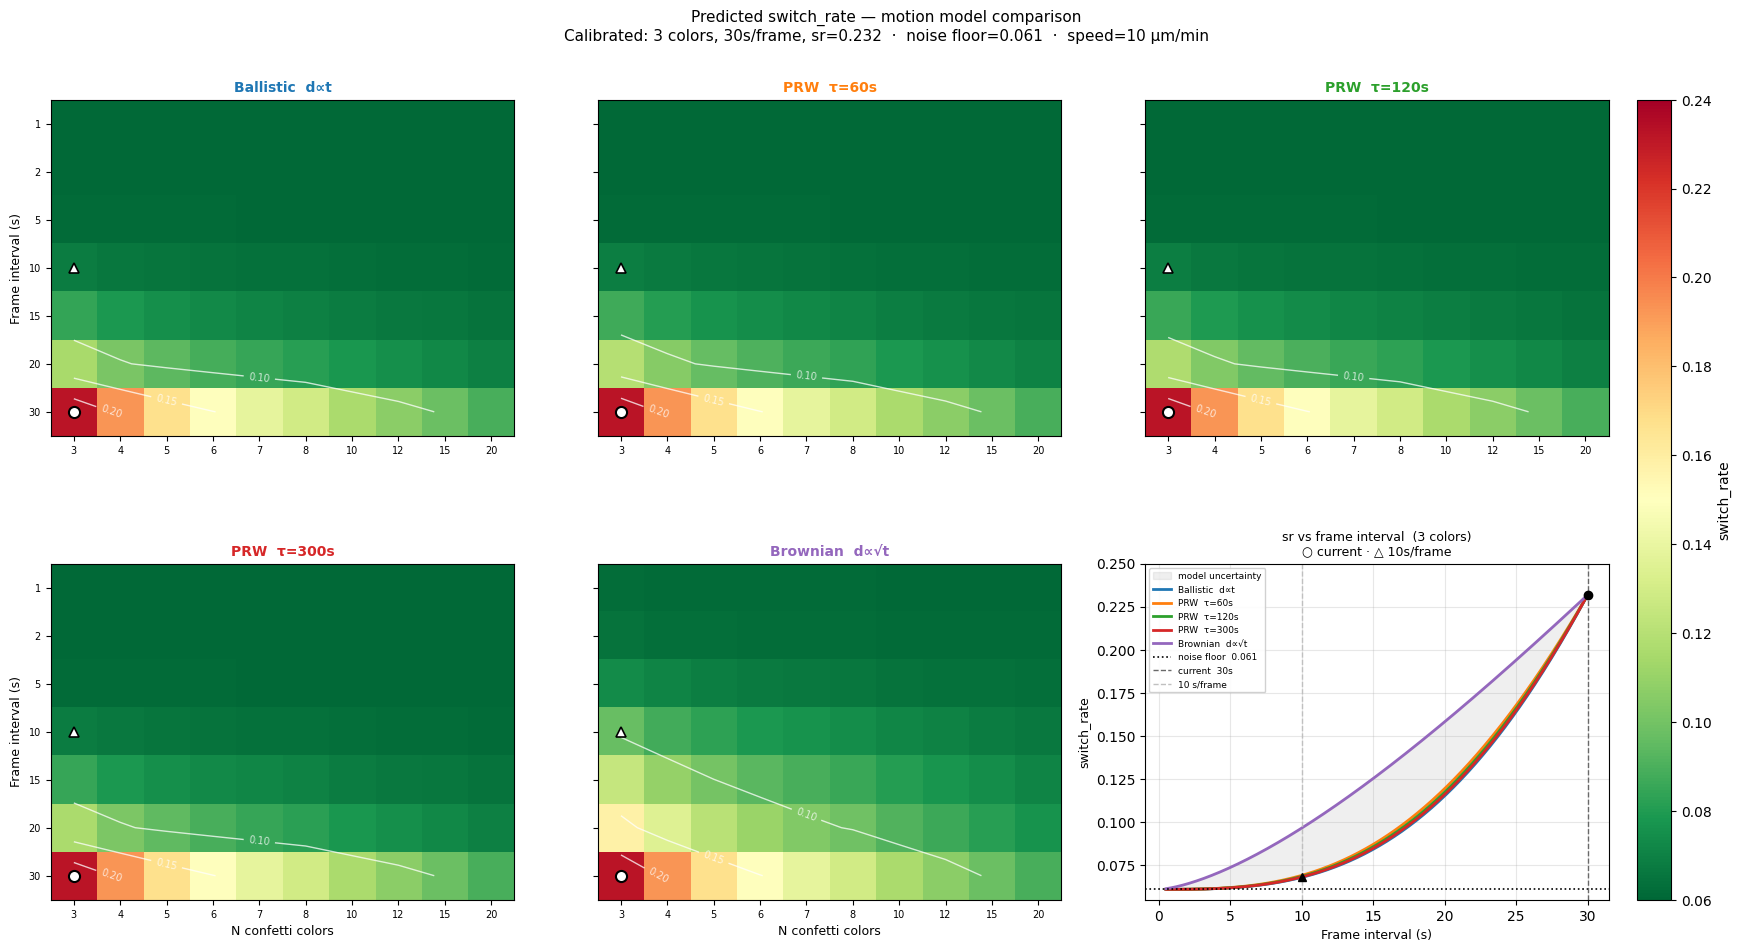

d(tf) [µm]  (D0=5.0 µm at 30s/frame)
 t(s)  Ballistic  d∝t    PRW  τ=60s   PRW  τ=120s   PRW  τ=300s  Brownian  d∝√t
    1          0.17          0.18          0.17          0.17          0.91
    2          0.33          0.36          0.35          0.34          1.29
    5          0.83          0.89          0.86          0.84          2.04
   10          1.67          1.76          1.71          1.69          2.89
   15          2.50          2.60          2.55          2.52          3.54
   20          3.33          3.42          3.38          3.35          4.08
   30          5.00          5.00          5.00          5.00          5.00


In [22]:
# §8b — 5 motion models in a 2×3 grid, with explanation panel

def _pred_sr_model(nc, tf, d_func):
    d = d_func(tf)
    p_comp = 1.0 - np.exp(-lambda_cal * d**3 / nc)
    return P_NOISE + (1.0 - P_NOISE) * p_comp

def _make_d_prw(tau):
    def _f(t):
        return t - tau * (1.0 - np.exp(-t / tau))
    ref = _f(T_FRAME_CURRENT)
    return lambda tf: D0 * np.sqrt(_f(tf) / ref)

def _d_ballistic(tf):
    return D0 * (tf / T_FRAME_CURRENT)

def _d_brownian(tf):
    return D0 * np.sqrt(tf / T_FRAME_CURRENT)

MODELS = [
    ('Ballistic  d∝t',  _d_ballistic,      'C0'),
    ('PRW  τ=60s',       _make_d_prw(60),  'C1'),
    ('PRW  τ=120s',      _make_d_prw(120), 'C2'),
    ('PRW  τ=300s',      _make_d_prw(300), 'C3'),
    ('Brownian  d∝√t',  _d_brownian,       'C4'),
]

N_colors_range = [3, 4, 5, 6, 7, 8, 10, 12, 15, 20]
t_frame_range  = [1, 2, 5, 10, 15, 20, 30]

grids = {}
for title, d_func, _ in MODELS:
    g = np.zeros((len(t_frame_range), len(N_colors_range)))
    for i, tf in enumerate(t_frame_range):
        for j, nc in enumerate(N_colors_range):
            g[i, j] = _pred_sr_model(nc, tf, d_func)
    grids[title] = g

fig, axes = plt.subplots(2, 3, figsize=(19, 10))
# leave room on the right for a manual colorbar
fig.subplots_adjust(left=0.06, right=0.88, top=0.88, bottom=0.08,
                    hspace=0.38, wspace=0.18)
fig.suptitle(
    f'Predicted switch_rate — motion model comparison\n'
    f'Calibrated: {N_COLORS_CURRENT} colors, {int(T_FRAME_CURRENT)}s/frame, '
    f'sr={P_SWITCH_OBS:.3f}  ·  noise floor={P_NOISE:.3f}  ·  '
    f'speed={SPEED_UM_MIN:.0f} µm/min',
    fontsize=11, y=0.97,
)

vmin, vmax = 0.06, 0.24
ci   = N_colors_range.index(N_COLORS_CURRENT)
ti   = t_frame_range.index(int(T_FRAME_CURRENT))
ti10 = t_frame_range.index(10) if 10 in t_frame_range else None

hm_positions = [(0, 0), (0, 1), (0, 2), (1, 0), (1, 1)]
im = None

for (row, col), (title, d_func, clr) in zip(hm_positions, MODELS):
    ax = axes[row, col]
    g  = grids[title]
    im = ax.imshow(g, aspect='auto', cmap='RdYlGn_r', vmin=vmin, vmax=vmax)

    ax.set_xticks(range(len(N_colors_range)))
    ax.set_xticklabels(N_colors_range, fontsize=7)
    ax.set_yticks(range(len(t_frame_range)))
    ax.set_yticklabels(t_frame_range if col == 0 else [], fontsize=7)
    if row == 1:
        ax.set_xlabel('N confetti colors', fontsize=9)
    if col == 0:
        ax.set_ylabel('Frame interval (s)', fontsize=9)
    ax.set_title(title, fontsize=10, color=clr, fontweight='bold')

    levels = [v for v in [0.10, 0.15, 0.20] if g.min() < v < g.max()]
    if levels:
        CS = ax.contour(g, levels=levels, colors='white', linewidths=1.0, alpha=0.75)
        ax.clabel(CS, fmt='%.2f', fontsize=7)

    ax.plot(ci, ti, 'wo', ms=8, markeredgecolor='black', markeredgewidth=1.5, zorder=5)
    if ti10 is not None:
        ax.plot(0, ti10, 'w^', ms=7, markeredgecolor='black', markeredgewidth=1.2, zorder=5)

# colorbar on the far right, spanning both rows
cbar_ax = fig.add_axes([0.895, 0.08, 0.018, 0.80])
fig.colorbar(im, cax=cbar_ax, label='switch_rate')

# ── explanation panel ─────────────────────────────────────────────────────────
ax_exp = axes[1, 2]
tf_cont = np.linspace(0.5, T_FRAME_CURRENT, 400)

sr_ball = np.array([_pred_sr_model(N_COLORS_CURRENT, tf, _d_ballistic) for tf in tf_cont])
sr_brow = np.array([_pred_sr_model(N_COLORS_CURRENT, tf, _d_brownian)  for tf in tf_cont])
ax_exp.fill_between(tf_cont, sr_ball, sr_brow, alpha=0.12, color='gray',
                    label='model uncertainty')

for title, d_func, clr in MODELS:
    sr_curve = [_pred_sr_model(N_COLORS_CURRENT, tf, d_func) for tf in tf_cont]
    ax_exp.plot(tf_cont, sr_curve, color=clr, lw=2, label=title)

ax_exp.axhline(P_NOISE, color='black', ls=':', lw=1.2,
               label=f'noise floor  {P_NOISE:.3f}')
ax_exp.axvline(T_FRAME_CURRENT, color='dimgray', ls='--', lw=1.0,
               label=f'current  {int(T_FRAME_CURRENT)}s')
ax_exp.axvline(10, color='silver', ls='--', lw=1.0, label='10 s/frame')

ax_exp.set_xlabel('Frame interval (s)', fontsize=9)
ax_exp.set_ylabel('switch_rate', fontsize=9)
ax_exp.set_title(
    f'sr vs frame interval  ({N_COLORS_CURRENT} colors)\n○ current · △ 10s/frame',
    fontsize=9,
)
ax_exp.set_ylim(0.055, 0.25)
ax_exp.legend(fontsize=6.5, loc='upper left', framealpha=0.9)
ax_exp.grid(alpha=0.3)
ax_exp.plot(T_FRAME_CURRENT,
            _pred_sr_model(N_COLORS_CURRENT, T_FRAME_CURRENT, _d_ballistic),
            'ko', ms=6, zorder=5)
ax_exp.plot(10, _pred_sr_model(N_COLORS_CURRENT, 10, _d_ballistic),
            'k^', ms=6, zorder=5)

plt.savefig('predicted_switch_rate_models.png', dpi=140, bbox_inches='tight')
plt.show()

# displacement table
print(f"d(tf) [µm]  (D0={D0:.1f} µm at {int(T_FRAME_CURRENT)}s/frame)")
print(f"{'t(s)':>5}  " + "  ".join(f"{t:>12}" for t, _, _ in MODELS))
for tf in t_frame_range:
    vals = [d_func(tf) for _, d_func, _ in MODELS]
    print(f"{tf:>5}  " + "  ".join(f"{v:>12.2f}" for v in vals))

In [23]:
# §8c — target table: what acquisition parameters reach each switch_rate goal?

TARGETS = [0.15, 0.10, 0.07]

print(f"=== Colors needed to hit target  (frame rate fixed at {int(T_FRAME_CURRENT)}s/frame) ===")
print(f"{'target sr':>10}  {'min N_colors':>12}  {'predicted sr':>12}")
for target in TARGETS:
    if target <= P_NOISE:
        print(f"{target:>10.2f}  {'unreachable':>12}  (noise floor={P_NOISE:.3f})")
        continue
    for nc in range(N_COLORS_CURRENT, 300):
        if _pred_sr(nc, T_FRAME_CURRENT) <= target:
            print(f"{target:>10.2f}  {nc:>12d}  {_pred_sr(nc, T_FRAME_CURRENT):>12.3f}")
            break
    else:
        print(f"{target:>10.2f}  {'unreachable':>12}  (noise floor={P_NOISE:.3f})")

print(f"\n=== Maximum frame interval to hit target  ({N_COLORS_CURRENT} colors, current density) ===")
print(f"  (slowest acceptable acquisition — reduce to save phototoxicity / scan time)")
print(f"{'target sr':>10}  {'max t_frame':>12}  {'predicted sr':>12}")
for target in TARGETS:
    if target <= P_NOISE:
        print(f"{target:>10.2f}  {'unreachable':>12}  (noise floor={P_NOISE:.3f})")
        continue
    # search from current frame rate downward to find largest t that still meets target
    found = False
    for tf_ds in range(int(T_FRAME_CURRENT * 10), 0, -1):
        tf = tf_ds / 10.0
        if _pred_sr(N_COLORS_CURRENT, tf) <= target:
            print(f"{target:>10.2f}  {tf:>11.1f}s  {_pred_sr(N_COLORS_CURRENT, tf):>12.3f}")
            found = True
            break
    if not found:
        print(f"{target:>10.2f}  {'unreachable at any frame rate — noise floor dominates':>12}")

print(f"\n=== Key acquisition scenarios ===")
print(f"{'scenario':42}  {'colors':>6}  {'t(s)':>5}  {'d(µm)':>6}  {'sr':>6}")
configs = [
    (N_COLORS_CURRENT, T_FRAME_CURRENT, 'current'),
    (5,  T_FRAME_CURRENT, f'+2 colors, {int(T_FRAME_CURRENT)}s/frame'),
    (N_COLORS_CURRENT, 10, f'{N_COLORS_CURRENT} colors, 10s/frame'),
    (5,  10, '5 colors, 10s/frame'),
    (N_COLORS_CURRENT, 5, f'{N_COLORS_CURRENT} colors, 5s/frame'),
]
for nc, tf, label in configs:
    d  = SPEED_UM_MIN / 60.0 * tf
    sr = _pred_sr(nc, tf)
    marker = '  <- current' if (nc == N_COLORS_CURRENT and tf == T_FRAME_CURRENT) else ''
    print(f"{label:42}  {nc:>6}  {tf:>5.0f}  {d:>6.2f}  {sr:>6.3f}{marker}")

print(f"\n  Noise floor (hard limit regardless of acquisition): {P_NOISE:.3f}")
print(f"  Reducible only by improving segmentation quality or Kalman state estimation.")

=== Colors needed to hit target  (frame rate fixed at 30s/frame) ===
 target sr  min N_colors  predicted sr
      0.15             7         0.138
      0.10            15         0.098
      0.07            63         0.070

=== Maximum frame interval to hit target  (3 colors, current density) ===
  (slowest acceptable acquisition — reduce to save phototoxicity / scan time)
 target sr   max t_frame  predicted sr
      0.15         23.7s         0.150
      0.10         17.8s         0.100
      0.07         10.9s         0.070

=== Key acquisition scenarios ===
scenario                                    colors   t(s)   d(µm)      sr
current                                          3     30    5.00   0.232  <- current
+2 colors, 30s/frame                             5     30    5.00   0.168
3 colors, 10s/frame                              3     10    1.67   0.068
5 colors, 10s/frame                              5     10    1.67   0.065
3 colors, 5s/frame                               

## 9. Within-class confetti discriminability

**Key question:** is the *continuous* 3D confetti vector (not just argmax) discriminative
within a color class? If red cell A has [0.80, 0.15, 0.05] and red cell B has [0.92, 0.04, 0.04],
they are separable — the argmax is the same but the ratio is different.

**Why this matters for global confetti solving:**
- Current `w_color` cost uses L2-normalised cosine distance to the track's *last observation* —
  noisy and doesn't exploit temporal accumulation.
- If within-class variation is real, a track's *running mean* confetti vector becomes a stable
  fingerprint over 30+ frames and can resolve confusion between same-colour neighbours.
- If within-class pairs are all cosine ≈ 1.0, the 3D vector is degenerate — no fingerprinting
  approach can help and faster acquisition is the only lever.

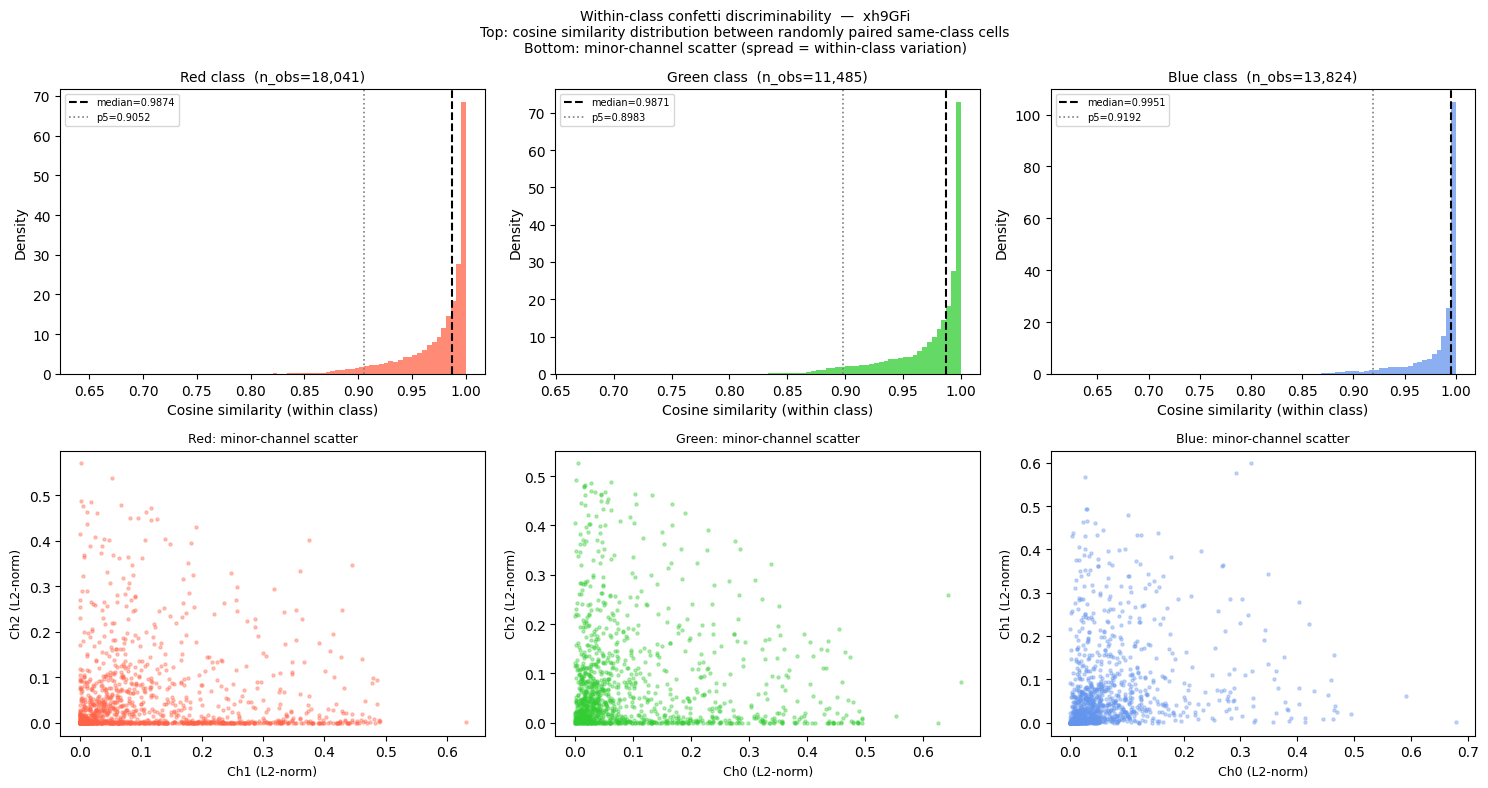

=== Within-class cosine similarity  (~263 cells per class) ===
   Class   n_obs     median         p5        p95   % > 0.99   % > 0.95
     Red   18041     0.9874     0.9052     0.9998       45.3       81.7
   Green   11485     0.9871     0.8983     0.9998       45.2       79.7
    Blue   13824     0.9951     0.9192     0.9999       62.2       87.9

=== Effective discriminability per class ===

  Red: median cosine=0.9874  p5=0.9052 (25.2° apart)
         45% of pairs cosine > 0.99  →  rough K=2.2x sub-clusters
         equivalent to 6.6 effective colors → predicted sr=0.143 (current=0.232)

  Green: median cosine=0.9871  p5=0.8983 (26.1° apart)
         45% of pairs cosine > 0.99  →  rough K=2.2x sub-clusters
         equivalent to 6.6 effective colors → predicted sr=0.142 (current=0.232)

  Blue: median cosine=0.9951  p5=0.9192 (23.2° apart)
         62% of pairs cosine > 0.99  →  rough K=1.6x sub-clusters
         equivalent to 4.8 effective colors → predicted sr=0.171 (current=0.23

In [25]:
# §9a — pool L2-normalised confetti vectors per color class (all frames, all cells)

CH_NAMES  = ['Red', 'Green', 'Blue']
CH_COLORS = ['tomato', 'limegreen', 'cornflowerblue']
N_SAMPLE  = 1200   # vectors sampled per class for pairwise comparisons

uid_d  = uIDs[0]
intens_d = c_intensities_per_uid[uid_d]

all_max_d = [float(np.max(v)) for td in intens_d.values() for v in td.values()]
dim_thr_d = float(np.quantile(all_max_d, 0.10))

vecs_by_class = {0: [], 1: [], 2: []}
for t, cell_dict in intens_d.items():
    for cid, iv in cell_dict.items():
        if float(np.max(iv)) <= dim_thr_d:
            continue
        norm = float(np.linalg.norm(iv))
        if norm < 1e-8:
            continue
        v = (iv / norm).astype(np.float32)
        vecs_by_class[int(np.argmax(iv))].append(v)

rng = np.random.default_rng(42)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle(
    f'Within-class confetti discriminability  —  {uid_d}\n'
    'Top: cosine similarity distribution between randomly paired same-class cells\n'
    'Bottom: minor-channel scatter (spread = within-class variation)',
    fontsize=10,
)

within_sims_all = {}
samples_by_class = {}

for ch in range(3):
    vecs  = np.array(vecs_by_class[ch], dtype=np.float32)
    n_obs = len(vecs)
    idx   = rng.choice(n_obs, min(N_SAMPLE, n_obs), replace=False)
    samp  = vecs[idx]
    samples_by_class[ch] = samp

    # pairwise cosine similarities (already L2-normalised)
    sims = (samp @ samp.T).astype(np.float64)
    np.fill_diagonal(sims, np.nan)
    ws   = sims[~np.isnan(sims)]
    within_sims_all[ch] = ws

    ax = axes[0, ch]
    ax.hist(ws, bins=80, color=CH_COLORS[ch], alpha=0.75, edgecolor='none', density=True)
    med = float(np.nanmedian(ws))
    p5  = float(np.nanpercentile(ws, 5))
    ax.axvline(med, color='k',    ls='--', lw=1.5, label=f'median={med:.4f}')
    ax.axvline(p5,  color='gray', ls=':',  lw=1.2, label=f'p5={p5:.4f}')
    ax.set_title(f'{CH_NAMES[ch]} class  (n_obs={n_obs:,})', fontsize=10)
    ax.set_xlabel('Cosine similarity (within class)')
    ax.set_ylabel('Density')
    ax.legend(fontsize=7)

    ax2 = axes[1, ch]
    non_dom = [i for i in range(3) if i != ch]
    ax2.scatter(samp[:, non_dom[0]], samp[:, non_dom[1]],
                alpha=0.35, s=5, color=CH_COLORS[ch], rasterized=True)
    ax2.set_xlabel(f'Ch{non_dom[0]} (L2-norm)', fontsize=9)
    ax2.set_ylabel(f'Ch{non_dom[1]} (L2-norm)', fontsize=9)
    ax2.set_title(f'{CH_NAMES[ch]}: minor-channel scatter', fontsize=9)

plt.tight_layout()
plt.show()

# ── Summary statistics ─────────────────────────────────────────────────────────
cells_per_frame_d = [len(np.unique(coastal_instances_per_uid[uid_d][t])) - 1
                     for t in range(coastal_instances_per_uid[uid_d].shape[0])]
N_c_est = int(np.mean(cells_per_frame_d)) // 3

print(f'=== Within-class cosine similarity  (~{N_c_est} cells per class) ===')
print(f'  {"Class":>6}  {"n_obs":>6}  {"median":>9}  {"p5":>9}  {"p95":>9}  '
      f'{"% > 0.99":>9}  {"% > 0.95":>9}')
for ch in range(3):
    ws    = within_sims_all[ch]
    pct99 = 100 * float(np.mean(ws > 0.99))
    pct95 = 100 * float(np.mean(ws > 0.95))
    print(f'  {CH_NAMES[ch]:>6}  {len(vecs_by_class[ch]):>6}  '
          f'{np.nanmedian(ws):>9.4f}  {np.nanpercentile(ws, 5):>9.4f}  '
          f'{np.nanpercentile(ws, 95):>9.4f}  {pct99:>9.1f}  {pct95:>9.1f}')

print()
print('=== Effective discriminability per class ===')
print()
for ch in range(3):
    ws    = within_sims_all[ch]
    med   = float(np.nanmedian(ws))
    p5    = float(np.nanpercentile(ws, 5))
    pct99 = float(np.mean(ws > 0.99))
    ang5  = float(np.degrees(np.arccos(np.clip(p5, -1.0, 1.0))))
    # Rough effective K: fraction indistinguishable at cosine>0.99 collapses to 1 sub-cluster;
    # fraction below gives additional resolvable sub-groups.
    K_eff = max(1.0, 1.0 / max(pct99, 1e-3))
    N_eff = N_COLORS_CURRENT * K_eff
    sr_if = _pred_sr(N_eff, T_FRAME_CURRENT)
    print(f'  {CH_NAMES[ch]}: median cosine={med:.4f}  p5={p5:.4f} ({ang5:.1f}° apart)')
    print(f'         {100*pct99:.0f}% of pairs cosine > 0.99  →  rough K={K_eff:.1f}x sub-clusters')
    print(f'         equivalent to {N_eff:.1f} effective colors → predicted sr={sr_if:.3f} '
          f'(current={P_SWITCH_OBS:.3f})')
    print()

# ── Overall verdict ────────────────────────────────────────────────────────────
all_ws_combined = np.concatenate(list(within_sims_all.values()))
overall_pct99   = float(np.mean(all_ws_combined > 0.99))
overall_pct95   = float(np.mean(all_ws_combined > 0.95))
print('=== Verdict: is global confetti solving worth pursuing? ===')
print(f'  Overall: {100*overall_pct99:.0f}% of within-class pairs cosine > 0.99')
print(f'           {100*overall_pct95:.0f}% of within-class pairs cosine > 0.95')
print()
if overall_pct99 > 0.80:
    print('  DEGENERATE: the continuous 3D confetti vector is nearly identical within each')
    print('  color class. Sub-class fingerprinting cannot improve switch_rate at 30s/frame.')
    print('  → Faster acquisition (≤10s/frame) is the only meaningful path forward.')
elif overall_pct99 > 0.50:
    print('  MARGINAL: moderate within-class variation. Accumulated fingerprinting may give')
    print('  small gains (< 0.02 switch_rate), but won\'t close the gap.')
    print('  → Run the experiment on 10s/frame data where the signal will be more isolated.')
else:
    print('  INFORMATIVE: substantial within-class variation. Implement accumulated track')
    print('  fingerprint in the LAP cost — this may improve switch_rate meaningfully.')
    print('  → Implement §9b before acquiring new data.')

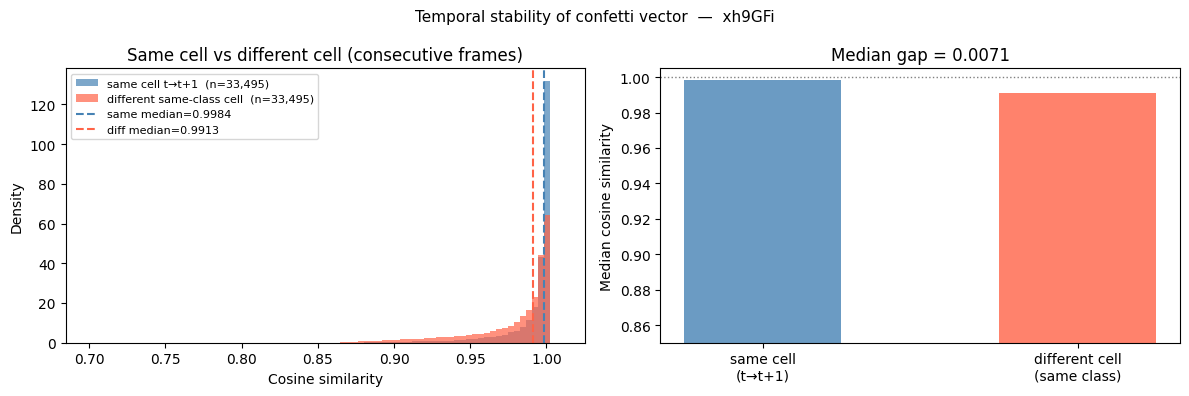

=== Temporal stability: same cell vs different same-class cell ===
  Same cell  (t → t+1):  median=0.9984  p5=0.9478  p95=1.0000
  Diff cell  (same cls): median=0.9913  p5=0.9115  p95=0.9999
  Gap (same − diff):     0.0071

  Distribution overlap:  73.7%

  d-prime (signal-to-noise): 0.484
    > 1.0: fingerprint is discriminative enough to use
    < 0.5: distributions overlap too much to be useful

=== Verdict: is accumulated confetti fingerprinting viable? ===
  NOT VIABLE: gap=0.0071, d-prime=0.48.
  Within-class variation is frame noise, not cell-stable identity.
  No accumulated fingerprinting approach can exploit this signal.
  → Faster acquisition is the only path.


In [26]:
# §9b — Temporal stability of within-class confetti vectors
# ─────────────────────────────────────────────────────────────────────────────
# Strategy: at each consecutive frame pair (t, t+1), greedily match cells by
# nearest centroid (no tracking — pure position proxy for identity). Measure:
#   same_sim  = cosine similarity of matched cell's vector at t vs t+1
#   diff_sim  = cosine similarity of matched cell at t vs a random OTHER same-class cell at t+1
#
# If same_sim >> diff_sim: vectors are cell-stable → accumulated fingerprinting works.
# If same_sim ≈ diff_sim: vectors are noisy → minor-channel variation is frame noise only.

from skimage.measure import regionprops_table
from scipy.spatial import cKDTree

uid_s    = uIDs[0]
inst_s   = coastal_instances_per_uid[uid_s]
intens_s = c_intensities_per_uid[uid_s]
T_s      = inst_s.shape[0]

all_max_s = [float(np.max(v)) for td in intens_s.values() for v in td.values()]
dim_thr_s = float(np.quantile(all_max_s, 0.10))
pr_s      = pix_res[uid_s]
scale_s   = np.array([pr_s['z'], pr_s['y'], pr_s['x']], dtype=np.float32)

def _get_centroids_and_vecs(t):
    """Returns {cell_id: (centroid_um, norm_vec)} for non-dim cells at frame t."""
    out = {}
    props = regionprops_table(inst_s[t], properties=['label', 'centroid'])
    for lab, cz, cy, cx in zip(props['label'], props['centroid-0'],
                                props['centroid-1'], props['centroid-2']):
        iv = intens_s.get(t, {}).get(int(lab))
        if iv is None or float(np.max(iv)) <= dim_thr_s:
            continue
        norm = float(np.linalg.norm(iv))
        if norm < 1e-8:
            continue
        cent = np.array([cz, cy, cx], dtype=np.float32) * scale_s
        out[int(lab)] = (cent, (iv / norm).astype(np.float32))
    return out

rng2 = np.random.default_rng(7)
same_sims = []   # cosine(cell at t, same cell at t+1)
diff_sims = []   # cosine(cell at t, different same-class cell at t+1)

for t in range(T_s - 1):
    data_t  = _get_centroids_and_vecs(t)
    data_t1 = _get_centroids_and_vecs(t + 1)
    if len(data_t) < 5 or len(data_t1) < 5:
        continue

    ids_t  = list(data_t.keys())
    ids_t1 = list(data_t1.keys())
    cents_t  = np.array([data_t[i][0]  for i in ids_t])
    cents_t1 = np.array([data_t1[i][0] for i in ids_t1])

    tree = cKDTree(cents_t1)
    dists, nn_idx = tree.query(cents_t, k=1, workers=1)

    for i, (cid_t, dist, j) in enumerate(zip(ids_t, dists, nn_idx)):
        if dist > 15.0:   # skip if nearest neighbour is >15 µm away (likely gap)
            continue
        cid_t1_matched = ids_t1[j]

        vec_t   = data_t[cid_t][1]
        vec_t1  = data_t1[cid_t1_matched][1]
        ch_t    = int(np.argmax(vec_t))
        ch_t1   = int(np.argmax(vec_t1))

        if ch_t != ch_t1:   # skip cross-class pairs
            continue

        same_sims.append(float(np.dot(vec_t, vec_t1)))

        # Random other same-class cell at t+1
        same_class_t1 = [k for k in ids_t1 if int(np.argmax(data_t1[k][1])) == ch_t
                         and k != cid_t1_matched]
        if same_class_t1:
            other = rng2.choice(len(same_class_t1))
            vec_other = data_t1[same_class_t1[other]][1]
            diff_sims.append(float(np.dot(vec_t, vec_other)))

same_sims = np.array(same_sims)
diff_sims = np.array(diff_sims)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f'Temporal stability of confetti vector  —  {uid_s}', fontsize=11)

bins = np.linspace(0.7, 1.01, 80)
ax = axes[0]
ax.hist(same_sims, bins=bins, alpha=0.7, color='steelblue',
        label=f'same cell t→t+1  (n={len(same_sims):,})', density=True)
ax.hist(diff_sims, bins=bins, alpha=0.7, color='tomato',
        label=f'different same-class cell  (n={len(diff_sims):,})', density=True)
ax.axvline(np.median(same_sims), color='steelblue', ls='--', lw=1.5,
           label=f'same median={np.median(same_sims):.4f}')
ax.axvline(np.median(diff_sims), color='tomato',    ls='--', lw=1.5,
           label=f'diff median={np.median(diff_sims):.4f}')
ax.set_xlabel('Cosine similarity')
ax.set_ylabel('Density')
ax.set_title('Same cell vs different cell (consecutive frames)')
ax.legend(fontsize=8)

ax2 = axes[1]
gap = np.median(same_sims) - np.median(diff_sims)
ax2.bar(['same cell\n(t→t+1)', 'different cell\n(same class)'],
        [np.median(same_sims), np.median(diff_sims)],
        color=['steelblue', 'tomato'], alpha=0.8, width=0.5)
ax2.set_ylabel('Median cosine similarity')
ax2.set_title(f'Median gap = {gap:.4f}')
ax2.set_ylim(0.85, 1.005)
ax2.axhline(1.0, color='gray', ls=':', lw=1)

plt.tight_layout()
plt.show()

# ── Summary ───────────────────────────────────────────────────────────────────
print('=== Temporal stability: same cell vs different same-class cell ===')
print(f'  Same cell  (t → t+1):  median={np.median(same_sims):.4f}  '
      f'p5={np.percentile(same_sims, 5):.4f}  p95={np.percentile(same_sims, 95):.4f}')
print(f'  Diff cell  (same cls): median={np.median(diff_sims):.4f}  '
      f'p5={np.percentile(diff_sims, 5):.4f}  p95={np.percentile(diff_sims, 95):.4f}')
print(f'  Gap (same − diff):     {gap:.4f}')
print()

# Overlap coefficient (how much do the distributions overlap?)
h_same, edges = np.histogram(same_sims, bins=bins, density=True)
h_diff, _     = np.histogram(diff_sims, bins=bins, density=True)
bin_w = np.diff(edges)[0]
overlap = float(np.sum(np.minimum(h_same, h_diff)) * bin_w)

print(f'  Distribution overlap:  {100*overlap:.1f}%')
print()

# Discriminability (d-prime)
dprime = (np.mean(same_sims) - np.mean(diff_sims)) / np.sqrt(
    0.5 * (np.std(same_sims)**2 + np.std(diff_sims)**2)
)
print(f'  d-prime (signal-to-noise): {dprime:.3f}')
print(f'    > 1.0: fingerprint is discriminative enough to use')
print(f'    < 0.5: distributions overlap too much to be useful')
print()
print('=== Verdict: is accumulated confetti fingerprinting viable? ===')
if gap > 0.015 and dprime > 1.0:
    print(f'  VIABLE: gap={gap:.4f}, d-prime={dprime:.2f}.')
    print(f'  Same-cell vectors are measurably tighter than different-cell vectors.')
    print(f'  Accumulated track fingerprints will provide real discrimination signal.')
    print(f'  → Implement §9c: replace per-frame color cost with running track mean.')
elif gap > 0.005 and dprime > 0.5:
    print(f'  WEAK SIGNAL: gap={gap:.4f}, d-prime={dprime:.2f}.')
    print(f'  Some temporal stability but distributions heavily overlap.')
    print(f'  Fingerprinting may give marginal gains, unlikely to beat 0.02 switch_rate.')
    print(f'  → Not worth implementing before 10s/frame acquisition.')
else:
    print(f'  NOT VIABLE: gap={gap:.4f}, d-prime={dprime:.2f}.')
    print(f'  Within-class variation is frame noise, not cell-stable identity.')
    print(f'  No accumulated fingerprinting approach can exploit this signal.')
    print(f'  → Faster acquisition is the only path.')

In [27]:
# §9c — Accumulated confetti fingerprint sweep
# ─────────────────────────────────────────────────────────────────────────────
# track_sequence already maintains an EMA color per track:
#   track_colors[tid] = alpha * prev + (1-alpha) * new_obs
# Default alpha=0.9  →  ~10-frame effective memory.
# Accumulated fingerprint = alpha → 1.0  →  full-sequence running mean.
#
# If §9b's d-prime improves as √N with accumulation, higher alpha should help.
# If the variation is noise-dominated, alpha has no effect.

from coastal.abm import track_sequence

COLOR_EMA_SWEEP = [0.0, 0.9, 0.95, 0.99, 0.999]
# 0.0  = per-frame (no memory)
# 0.9  = current default (~10-frame effective memory)
# 0.99 = ~100-frame — full-sequence for 61-frame movies
# 0.999 = asymptotic limit

uid_c  = uIDs[0]
pr_c   = pix_res[uid_c]
inst_c = coastal_instances_per_uid[uid_c]
intens_c = c_intensities_per_uid[uid_c]
vol_c  = np.asarray(volumes[uid_c][0])

print(f'Color EMA sweep  —  {uid_c}')
print(f'{"alpha":>7}  {"eff_frames":>10}  {"continuity":>10}  {"switch_rate":>11}')

ema_results = {}
for alpha in COLOR_EMA_SWEEP:
    eff = 1.0 / (1.0 - alpha) if alpha < 1.0 else float('inf')
    tracks = track_sequence(
        instances_4d=inst_c, pix_res=pr_c,
        w_color=1.0, cell_intensities=intens_c,
        color_ema=alpha,
        chi2_gate=9.21, max_gap=1, max_cost=1.5,
    )
    sc = score_tracking(tracks, inst_c, vol_c,
                        ch_indices=CH_INDICES_MAP[uid_c], pix_res=pr_c, verbose=False)
    ema_results[alpha] = sc
    print(f'{alpha:>7.3f}  {eff:>10.0f}  '
          f'{sc["continuity"]["mean"]:>10.3f}  {sc["color_switch_rate"]:>11.3f}')
    gc.collect()

print()
best_alpha = min(ema_results, key=lambda a: ema_results[a]['color_switch_rate'])
best_sr    = ema_results[best_alpha]['color_switch_rate']
base_sr    = ema_results[0.9]['color_switch_rate']   # current default
print(f'Best alpha={best_alpha}  →  sr={best_sr:.3f}')
print(f'Improvement over current default (alpha=0.9, sr={base_sr:.3f}): '
      f'{base_sr - best_sr:+.3f}')
print()
print(f'For reference:')
print(f'  Current w_color=1.0, alpha=0.9:  sr={base_sr:.3f}')
print(f'  Acquisition at 10s/frame (pred): sr≈0.068  (model)')
print(f'  Noise floor:                     sr={P_NOISE:.3f}')

Color EMA sweep  —  xh9GFi
  alpha  eff_frames  continuity  switch_rate
track_sequence: 3324 tracks over 61 frames
Color assignment: 4817 dim cells excluded (dim_quantile=0.1, threshold=9.2034)
  0.000           1       0.840        0.200
track_sequence: 3313 tracks over 61 frames
Color assignment: 4817 dim cells excluded (dim_quantile=0.1, threshold=9.2034)
  0.900          10       0.838        0.232
track_sequence: 3315 tracks over 61 frames
Color assignment: 4817 dim cells excluded (dim_quantile=0.1, threshold=9.2034)
  0.950          20       0.839        0.236
track_sequence: 3291 tracks over 61 frames
Color assignment: 4817 dim cells excluded (dim_quantile=0.1, threshold=9.2034)
  0.990         100       0.839        0.239
track_sequence: 3336 tracks over 61 frames
Color assignment: 4817 dim cells excluded (dim_quantile=0.1, threshold=9.2034)
  0.999        1000       0.839        0.239

Best alpha=0.0  →  sr=0.200
Improvement over current default (alpha=0.9, sr=0.232): +0.032



## 10. Point cloud structure — do T cells follow persistent tissue highways?

Before using trajectory density as a tracking prior, verify that the density field
has real spatial structure (corridors, barriers) rather than being spatially flat.

**Flat field → no highways → idea is dead before implementation.**  
**Structured field → tissue architecture is encoded in cell positions → worth building a cost term.**

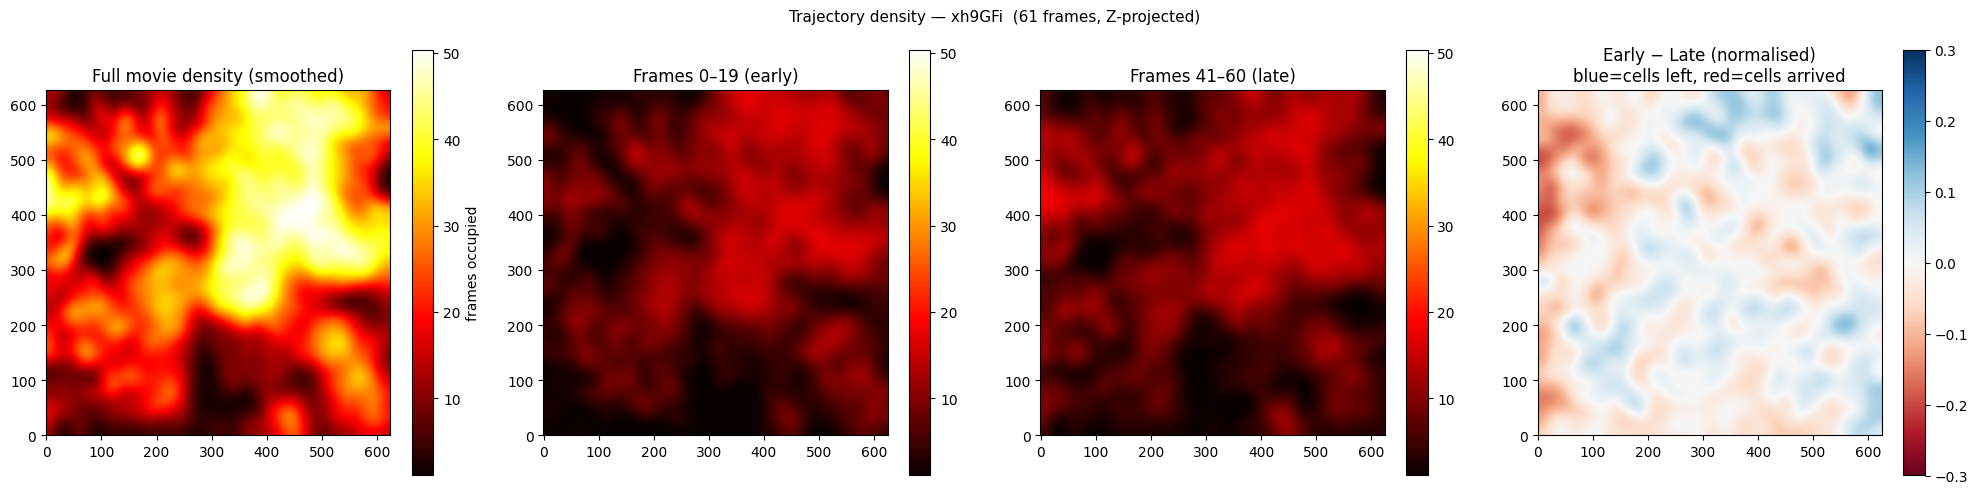

=== Trajectory density structure ===
  Spatial extent:        628 × 625 px  →  303 × 302 µm
  Mean frames occupied:  28.3 / 61
  CV (observed):         0.393
  CV (Poisson baseline): 0.188
  CV ratio (obs/Poisson):2.09x
  Temporal correlation (early vs late): r=0.815

  STRUCTURED: CV 2.1x above Poisson, r=0.81.
  Density field has persistent spatial corridors.
  → Proceed to §10b: build density-guided cost term.


In [28]:
# §10a — trajectory density diagnostic
# ─────────────────────────────────────────────────────────────────────────────
# Pool all cell centroids across all 61 frames → 2D XY density map (Z-projected).
# Three checks:
#   1. Spatial structure: is density uniform or does it have corridors/barriers?
#   2. Temporal stability: does structure in first-half match second-half?
#   3. CV vs Poisson baseline: is variation above random expectation?

from skimage.measure import regionprops_table
from scipy.ndimage import gaussian_filter

uid_p  = uIDs[0]
inst_p = coastal_instances_per_uid[uid_p]
pr_p   = pix_res[uid_p]
T_p, Z_p, H_p, W_p = inst_p.shape

# Accumulate 2D (Y, X) centroid counts — Z-projection, split into thirds for stability check
T_third = T_p // 3
density_full  = np.zeros((H_p, W_p), dtype=np.float32)
density_early = np.zeros((H_p, W_p), dtype=np.float32)  # first third
density_late  = np.zeros((H_p, W_p), dtype=np.float32)  # last third

for t in range(T_p):
    vol_t = inst_p[t]   # [Z, H, W]
    # Project across Z: any voxel with a cell label → mark that (y, x)
    occ = (vol_t > 0).any(axis=0).astype(np.float32)   # [H, W]
    density_full += occ
    if t < T_third:
        density_early += occ
    elif t >= T_p - T_third:
        density_late  += occ

# Smooth for visualisation (sigma ~ 1 cell diameter ≈ 7µm / 0.48µm/px ≈ 15px)
sigma_px = 15
dens_sm   = gaussian_filter(density_full,  sigma=sigma_px)
early_sm  = gaussian_filter(density_early, sigma=sigma_px)
late_sm   = gaussian_filter(density_late,  sigma=sigma_px)

# ── Plots ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle(f'Trajectory density — {uid_p}  ({T_p} frames, Z-projected)', fontsize=11)

im0 = axes[0].imshow(dens_sm, cmap='hot', origin='lower')
axes[0].set_title('Full movie density (smoothed)')
plt.colorbar(im0, ax=axes[0], label='frames occupied')

im1 = axes[1].imshow(early_sm, cmap='hot', origin='lower',
                     vmin=dens_sm.min(), vmax=dens_sm.max())
axes[1].set_title(f'Frames 0–{T_third-1} (early)')
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(late_sm, cmap='hot', origin='lower',
                     vmin=dens_sm.min(), vmax=dens_sm.max())
axes[2].set_title(f'Frames {T_p-T_third}–{T_p-1} (late)')
plt.colorbar(im2, ax=axes[2])

# Difference map: early - late (persistent structure cancels; transient shows up)
diff = (early_sm - late_sm) / (dens_sm.max() + 1e-8)
im3 = axes[3].imshow(diff, cmap='RdBu', origin='lower', vmin=-0.3, vmax=0.3)
axes[3].set_title('Early − Late (normalised)\nblue=cells left, red=cells arrived')
plt.colorbar(im3, ax=axes[3])

plt.tight_layout()
plt.show()

# ── Quantitative structure test ─────────────────────────────────────────────
# Mask border (gaussian smearing artefact) and background (tissue edge)
border = sigma_px * 2
interior = dens_sm[border:-border, border:-border]

# Exclude near-zero pixels (tissue boundary / outside FOV)
thresh = float(np.percentile(interior, 10))
mask   = interior > thresh
vals   = interior[mask]

cv_observed = float(vals.std() / vals.mean())
# Poisson baseline: for N_cells per voxel, CV_poisson = 1/sqrt(mean_count)
mean_count  = float(vals.mean())
cv_poisson  = 1.0 / np.sqrt(mean_count)

# Temporal correlation: does early predict late?
early_vals = early_sm[border:-border, border:-border][mask]
late_vals  = late_sm[border:-border,  border:-border][mask]
r_temporal = float(np.corrcoef(early_vals, late_vals)[0, 1])

print('=== Trajectory density structure ===')    
print(f'  Spatial extent:        {H_p} × {W_p} px  →  '
      f'{H_p*pr_p["y"]:.0f} × {W_p*pr_p["x"]:.0f} µm')
print(f'  Mean frames occupied:  {mean_count:.1f} / {T_p}')
print(f'  CV (observed):         {cv_observed:.3f}')
print(f'  CV (Poisson baseline): {cv_poisson:.3f}')
print(f'  CV ratio (obs/Poisson):{cv_observed/cv_poisson:.2f}x')
print(f'  Temporal correlation (early vs late): r={r_temporal:.3f}')
print()
cv_ratio = cv_observed / cv_poisson
if cv_ratio > 2.0 and r_temporal > 0.7:
    print(f'  STRUCTURED: CV {cv_ratio:.1f}x above Poisson, r={r_temporal:.2f}.')
    print(f'  Density field has persistent spatial corridors.')
    print(f'  → Proceed to §10b: build density-guided cost term.')
elif cv_ratio > 1.5 or r_temporal > 0.6:
    print(f'  WEAK STRUCTURE: CV {cv_ratio:.1f}x above Poisson, r={r_temporal:.2f}.')
    print(f'  Some spatial organisation but not strongly persistent.')
    print(f'  → Investigate further before committing to implementation.')
else:
    print(f'  FLAT: CV {cv_ratio:.1f}x above Poisson, r={r_temporal:.2f}.')
    print(f'  Density field is consistent with random movement.')
    print(f'  → No highway structure to exploit. Point cloud approach is not viable.')


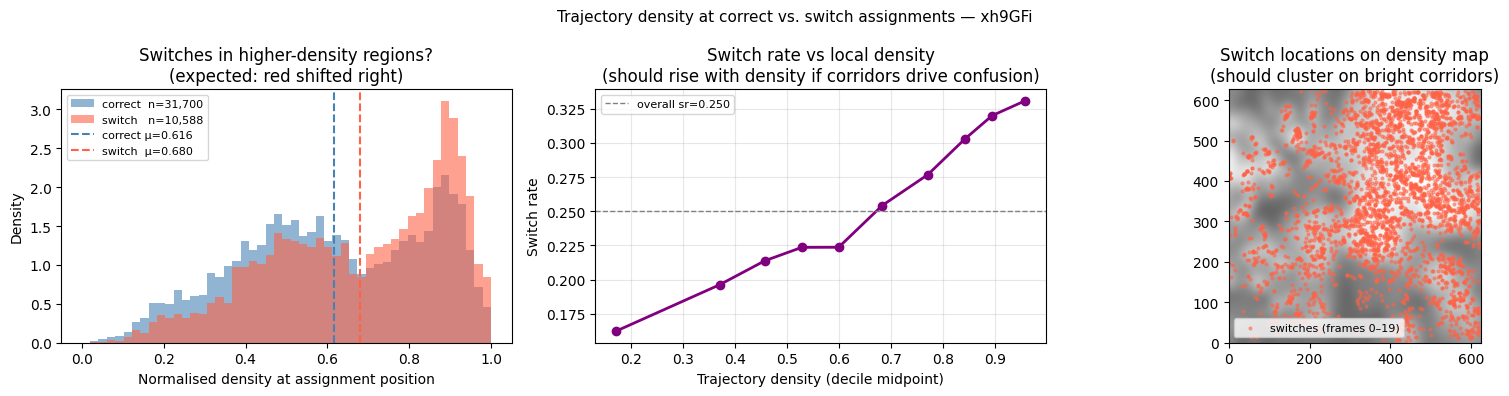

=== Density at correct vs. switch assignments ===
  Correct: n=31,700  mean=0.6161
  Switch:  n=10,588  mean=0.6804
  Gap (correct − switch): -0.0643  (switches in HIGHER density — expected)
  d-prime (magnitude):    0.288

  CONFIRMED: switches are concentrated in high-density corridor regions.
  Kalman fails where cells crowd; a topology-aware cost can exploit this.
  → §10c: implement void matching — where does space open in t+1?


In [30]:
# §10b — are switches concentrated in high-density regions?
# ─────────────────────────────────────────────────────────────────────────────
# Biological expectation: switches should happen where cells crowd together
# (high-density corridors), because that's where Kalman confuses identities.
# In open space Kalman is sufficient; in crowded corridors it fails.
#
# A density/corridor map is useful if: switches → high density (gap < 0).
# Not useful if: switches are density-agnostic (gap ≈ 0).

from scipy.spatial import cKDTree
from skimage.measure import regionprops_table

uid_pb    = uIDs[0]
inst_pb   = coastal_instances_per_uid[uid_pb]
intens_pb = c_intensities_per_uid[uid_pb]
pr_pb     = pix_res[uid_pb]
T_pb      = inst_pb.shape[0]

all_max_pb = [float(np.max(v)) for td in intens_pb.values() for v in td.values()]
dim_thr_pb = float(np.quantile(all_max_pb, 0.10))

# Density map from §10a — normalise to [0, 1]
dens_norm = (dens_sm - dens_sm.min()) / (dens_sm.max() - dens_sm.min() + 1e-8)

def _cents_pb(t):
    out = {}
    props = regionprops_table(inst_pb[t], properties=['label', 'centroid'])
    for lab, _, cy, cx in zip(props['label'], props['centroid-0'],
                               props['centroid-1'], props['centroid-2']):
        iv = intens_pb.get(t, {}).get(int(lab))
        if iv is None or float(np.max(iv)) <= dim_thr_pb:
            continue
        out[int(lab)] = (float(cy), float(cx), int(np.argmax(iv)))
    return out

switch_d  = []
correct_d = []
MAX_DIST_PX = 15.0 / pr_pb['y']

for t in range(T_pb - 1):
    data_t  = _cents_pb(t)
    data_t1 = _cents_pb(t + 1)
    if not data_t or not data_t1:
        continue
    ids_t  = list(data_t.keys())
    ids_t1 = list(data_t1.keys())
    arr_t  = np.array([[data_t[i][0],  data_t[i][1]]  for i in ids_t])
    arr_t1 = np.array([[data_t1[i][0], data_t1[i][1]] for i in ids_t1])
    tree = cKDTree(arr_t1)
    dists, nn = tree.query(arr_t, k=1, workers=1)
    for i, (cid_t, dist, j) in enumerate(zip(ids_t, dists, nn)):
        if dist > MAX_DIST_PX:
            continue
        cid_t1 = ids_t1[j]
        ch_t   = data_t[cid_t][2]
        ch_t1  = data_t1[cid_t1][2]
        y_px   = int(np.clip(round(data_t1[cid_t1][0]), 0, dens_norm.shape[0]-1))
        x_px   = int(np.clip(round(data_t1[cid_t1][1]), 0, dens_norm.shape[1]-1))
        d = float(dens_norm[y_px, x_px])
        (switch_d if ch_t != ch_t1 else correct_d).append(d)

switch_d  = np.array(switch_d)
correct_d = np.array(correct_d)

# ── Plots ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle(f'Trajectory density at correct vs. switch assignments — {uid_pb}', fontsize=11)

bins = np.linspace(0, 1, 50)
ax = axes[0]
ax.hist(correct_d, bins=bins, alpha=0.6, color='steelblue', density=True,
        label=f'correct  n={len(correct_d):,}')
ax.hist(switch_d,  bins=bins, alpha=0.6, color='tomato',    density=True,
        label=f'switch   n={len(switch_d):,}')
ax.axvline(np.mean(correct_d), color='steelblue', ls='--', lw=1.5,
           label=f'correct µ={np.mean(correct_d):.3f}')
ax.axvline(np.mean(switch_d),  color='tomato',    ls='--', lw=1.5,
           label=f'switch  µ={np.mean(switch_d):.3f}')
ax.set_xlabel('Normalised density at assignment position')
ax.set_ylabel('Density')
ax.set_title('Switches in higher-density regions?\n(expected: red shifted right)')
ax.legend(fontsize=8)

# Switch rate vs density decile — expected: rises with density
ax2 = axes[1]
all_d   = np.concatenate([correct_d, switch_d])
all_lab = np.concatenate([np.zeros(len(correct_d)), np.ones(len(switch_d))])
deciles = np.percentile(all_d, np.linspace(0, 100, 11))
bin_sr, bin_ctr = [], []
for lo, hi in zip(deciles[:-1], deciles[1:]):
    mask = (all_d >= lo) & (all_d < hi)
    if mask.sum() > 10:
        bin_sr.append(all_lab[mask].mean())
        bin_ctr.append((lo + hi) / 2)
ax2.plot(bin_ctr, bin_sr, 'o-', color='purple', lw=2)
ax2.axhline(all_lab.mean(), color='gray', ls='--', lw=1,
            label=f'overall sr={all_lab.mean():.3f}')
ax2.set_xlabel('Trajectory density (decile midpoint)')
ax2.set_ylabel('Switch rate')
ax2.set_title('Switch rate vs local density\n(should rise with density if corridors drive confusion)')
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

# Spatial overlay: where do switches occur?
ax3 = axes[2]
ax3.imshow(dens_sm, cmap='gray', origin='lower', alpha=0.6)
sw_yx = []
for t in range(min(T_pb-1, 20)):
    data_t  = _cents_pb(t)
    data_t1 = _cents_pb(t + 1)
    if not data_t or not data_t1:
        continue
    ids_t1 = list(data_t1.keys())
    arr_t1 = np.array([[data_t1[i][0], data_t1[i][1]] for i in ids_t1])
    tree   = cKDTree(arr_t1)
    ids_t  = list(data_t.keys())
    arr_t  = np.array([[data_t[i][0], data_t[i][1]] for i in ids_t])
    dists, nn = tree.query(arr_t, k=1, workers=1)
    for i, (cid_t, dist, j) in enumerate(zip(ids_t, dists, nn)):
        if dist > MAX_DIST_PX:
            continue
        if data_t[cid_t][2] != data_t1[ids_t1[j]][2]:
            sw_yx.append((data_t1[ids_t1[j]][0], data_t1[ids_t1[j]][1]))
if sw_yx:
    sw_yx = np.array(sw_yx)
    ax3.scatter(sw_yx[:, 1], sw_yx[:, 0], c='tomato', s=4, alpha=0.5,
                label='switches (frames 0–19)')
ax3.set_title('Switch locations on density map\n(should cluster on bright corridors)')
ax3.legend(fontsize=8)

plt.tight_layout()
plt.show()

# ── Summary ──────────────────────────────────────────────────────────────────
gap = float(np.mean(correct_d) - np.mean(switch_d))   # negative = switches in higher density
dprime_d = abs(gap) / np.sqrt(0.5 * (np.std(correct_d)**2 + np.std(switch_d)**2))

print('=== Density at correct vs. switch assignments ===')
print(f'  Correct: n={len(correct_d):,}  mean={np.mean(correct_d):.4f}')
print(f'  Switch:  n={len(switch_d):,}  mean={np.mean(switch_d):.4f}')
print(f'  Gap (correct − switch): {gap:.4f}  '
      f'({"switches in HIGHER density — expected" if gap < 0 else "switches in LOWER density — unexpected"})')
print(f'  d-prime (magnitude):    {dprime_d:.3f}')
print()
if gap < -0.01 and dprime_d > 0.2:
    print('  CONFIRMED: switches are concentrated in high-density corridor regions.')
    print('  Kalman fails where cells crowd; a topology-aware cost can exploit this.')
    print('  → §10c: implement void matching — where does space open in t+1?')
elif abs(gap) < 0.01:
    print('  FLAT: switches are density-agnostic. Corridor topology will not help.')
else:
    print(f'  Unexpected direction (gap={gap:.4f}). Investigate before proceeding.')


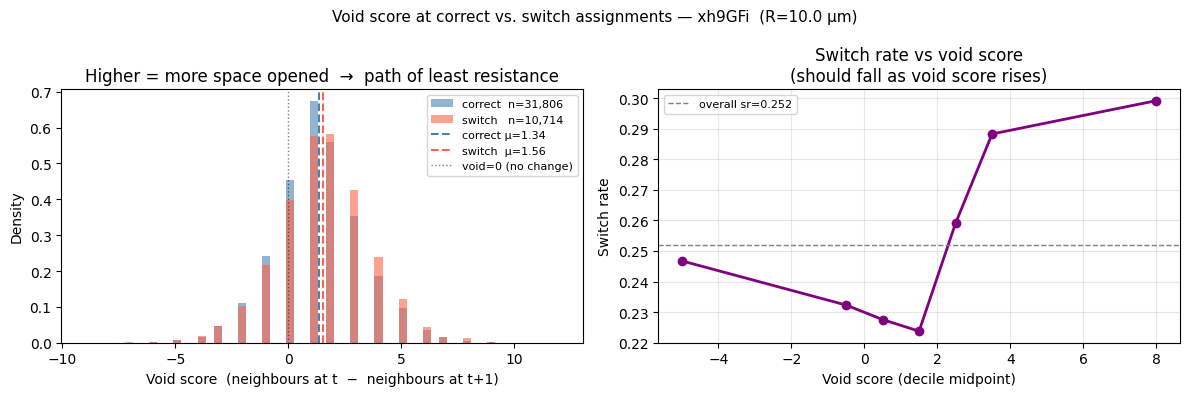

=== Void score at correct vs. switch assignments ===
  Correct: n=31,806  mean=1.337  std=1.962
  Switch:  n=10,714  mean=1.556  std=2.051
  Gap (correct − switch):  -0.218
  d-prime:                 -0.109

  NOT PREDICTIVE: void score does not separate correct from switch.
  Collective rearrangement is not a useful signal for this data.


In [31]:
# §10c — void matching diagnostic
# ─────────────────────────────────────────────────────────────────────────────
# For each detection at t+1, score how much space opened around it:
#   void_score = (cells within R at t) − (cells within R at t+1, excl. self)
# Positive = neighbours moved away → freshly vacated space → path of least resistance.
# Negative = cells converged here → crowding increased.
#
# Compare void_score at correct vs. switch assignments.
# If correct > switch: void matching will improve LAP assignment.

from scipy.spatial import cKDTree
from skimage.measure import regionprops_table

uid_v    = uIDs[0]
inst_v   = coastal_instances_per_uid[uid_v]
intens_v = c_intensities_per_uid[uid_v]
pr_v     = pix_res[uid_v]
T_v      = inst_v.shape[0]

all_max_v = [float(np.max(x)) for td in intens_v.values() for x in td.values()]
dim_thr_v = float(np.quantile(all_max_v, 0.10))

VOID_R_UM = 10.0   # neighbourhood radius (≈ 1.5 cell diameters)

def _cents_v(t):
    """{ cell_id: (y_um, x_um, dominant_ch) } for non-dim cells."""
    out = {}
    props = regionprops_table(inst_v[t], properties=['label', 'centroid'])
    for lab, _, cy, cx in zip(props['label'], props['centroid-0'],
                               props['centroid-1'], props['centroid-2']):
        iv = intens_v.get(t, {}).get(int(lab))
        if iv is None or float(np.max(iv)) <= dim_thr_v:
            continue
        out[int(lab)] = (cy * pr_v['y'], cx * pr_v['x'], int(np.argmax(iv)))
    return out

switch_vs  = []   # void_score at switch assignments
correct_vs = []   # void_score at correct assignments
MAX_DIST_UM = 15.0

for t in range(T_v - 1):
    data_t  = _cents_v(t)
    data_t1 = _cents_v(t + 1)
    if not data_t or not data_t1:
        continue

    ids_t   = list(data_t.keys())
    ids_t1  = list(data_t1.keys())
    arr_t   = np.array([[data_t[i][0],  data_t[i][1]]  for i in ids_t],  np.float32)
    arr_t1  = np.array([[data_t1[i][0], data_t1[i][1]] for i in ids_t1], np.float32)

    tree_t  = cKDTree(arr_t)
    tree_t1 = cKDTree(arr_t1)

    # void_score per detection at t+1
    n_t_near  = np.array([len(tree_t.query_ball_point(p, VOID_R_UM))  for p in arr_t1], np.float32)
    n_t1_near = np.array([len(tree_t1.query_ball_point(p, VOID_R_UM)) for p in arr_t1], np.float32)
    void_scores = n_t_near - (n_t1_near - 1)   # subtract self from t+1 count

    # Nearest-centroid matching (proxy for identity) to label correct / switch
    tree_match = cKDTree(arr_t1)
    dists, nn  = tree_match.query(arr_t, k=1, workers=1)

    for i, (cid_t, dist, j) in enumerate(zip(ids_t, dists, nn)):
        if dist > MAX_DIST_UM / pr_v['y']:   # pixel units
            continue
        cid_t1 = ids_t1[j]
        vs = float(void_scores[j])
        if data_t[cid_t][2] != data_t1[cid_t1][2]:
            switch_vs.append(vs)
        else:
            correct_vs.append(vs)

switch_vs  = np.array(switch_vs,  np.float32)
correct_vs = np.array(correct_vs, np.float32)

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f'Void score at correct vs. switch assignments — {uid_v}  (R={VOID_R_UM} µm)', fontsize=11)

lo = min(switch_vs.min(), correct_vs.min())
hi = max(switch_vs.max(), correct_vs.max())
bins = np.linspace(lo, hi, 60)

ax = axes[0]
ax.hist(correct_vs, bins=bins, alpha=0.6, color='steelblue', density=True,
        label=f'correct  n={len(correct_vs):,}')
ax.hist(switch_vs,  bins=bins, alpha=0.6, color='tomato',    density=True,
        label=f'switch   n={len(switch_vs):,}')
ax.axvline(np.mean(correct_vs), color='steelblue', ls='--', lw=1.5,
           label=f'correct µ={np.mean(correct_vs):.2f}')
ax.axvline(np.mean(switch_vs),  color='tomato',    ls='--', lw=1.5,
           label=f'switch  µ={np.mean(switch_vs):.2f}')
ax.axvline(0, color='black', ls=':', lw=1, alpha=0.5, label='void=0 (no change)')
ax.set_xlabel(f'Void score  (neighbours at t  −  neighbours at t+1)')
ax.set_ylabel('Density')
ax.set_title('Higher = more space opened  →  path of least resistance')
ax.legend(fontsize=8)

# Switch rate vs void score decile
ax2 = axes[1]
all_vs  = np.concatenate([correct_vs, switch_vs])
all_lab = np.concatenate([np.zeros(len(correct_vs)), np.ones(len(switch_vs))])
deciles = np.percentile(all_vs, np.linspace(0, 100, 11))
bin_sr, bin_ctr = [], []
for lo_d, hi_d in zip(deciles[:-1], deciles[1:]):
    mask = (all_vs >= lo_d) & (all_vs < hi_d)
    if mask.sum() > 10:
        bin_sr.append(all_lab[mask].mean())
        bin_ctr.append((lo_d + hi_d) / 2)
ax2.plot(bin_ctr, bin_sr, 'o-', color='purple', lw=2)
ax2.axhline(all_lab.mean(), color='gray', ls='--', lw=1,
            label=f'overall sr={all_lab.mean():.3f}')
ax2.set_xlabel('Void score (decile midpoint)')
ax2.set_ylabel('Switch rate')
ax2.set_title('Switch rate vs void score\n(should fall as void score rises)')
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ── Summary ───────────────────────────────────────────────────────────────────
gap = float(np.mean(correct_vs) - np.mean(switch_vs))
dprime_v = gap / np.sqrt(0.5 * (np.std(correct_vs)**2 + np.std(switch_vs)**2))

print('=== Void score at correct vs. switch assignments ===')
print(f'  Correct: n={len(correct_vs):,}  mean={np.mean(correct_vs):.3f}  std={np.std(correct_vs):.3f}')
print(f'  Switch:  n={len(switch_vs):,}  mean={np.mean(switch_vs):.3f}  std={np.std(switch_vs):.3f}')
print(f'  Gap (correct − switch):  {gap:.3f}')
print(f'  d-prime:                 {dprime_v:.3f}')
print()
if gap > 0.1 and dprime_v > 0.2:
    print('  PREDICTIVE: correct assignments move into more vacated space.')
    print('  Void matching captures path-of-least-resistance signal beyond Kalman.')
    print('  → §10d: add w_void cost term to track_sequence in abm.py.')
elif gap > 0.02:
    print('  WEAK: small but consistent void signal. Worth a quick §10d implementation.')
else:
    print('  NOT PREDICTIVE: void score does not separate correct from switch.')
    print('  Collective rearrangement is not a useful signal for this data.')


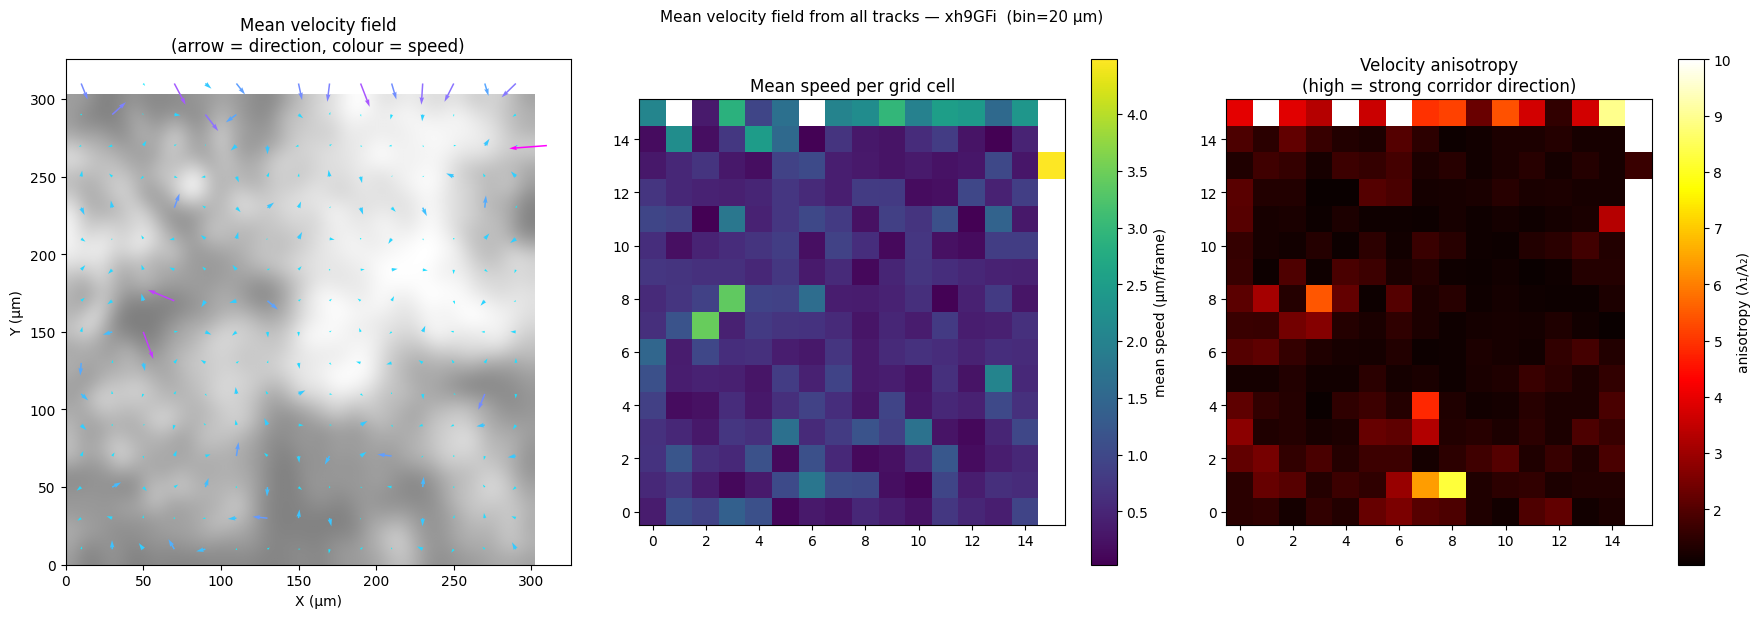

=== Mean velocity field structure ===
  Grid: 16 × 16 bins  (20 µm each)
  Bins with ≥5 observations: 239 / 256
  Mean speed:    0.74 µm/frame  (max 4.48)
  Spatial coherence (mean cos between neighbouring bins): 0.157
    1.0 = perfectly aligned corridors
    0.0 = random directions — no highway structure
   -1.0 = alternating directions
  Mean anisotropy: 1.75  (1.0 = isotropic, >3 = strongly directional)

  INCOHERENT: cells move in all directions at every position.
  No highway directional signal to exploit.


In [32]:
# §10d — mean velocity field from all tracks
# ─────────────────────────────────────────────────────────────────────────────
# Pool velocity vectors from all tracks into a 2D spatial grid.
# At each grid cell: mean velocity vector = local corridor direction.
#
# Key question: is this field spatially coherent?
#   Coherent  → tissue channels force cells in consistent directions → use as prior.
#   Random    → cells move in all directions at every position → no highway signal.
#
# Also compute anisotropy (eigenvalue ratio of local velocity covariance):
#   High anisotropy → corridor is directional (elongated flow).
#   Low anisotropy  → isotropic random walk locally.

uid_h  = uIDs[0]
pr_h   = pix_res[uid_h]
tracks_h = tracks_coastal_c_per_uid[uid_h]   # {tid: {t: pos_um [3]}}

# Grid: bin positions into BIN_UM × BIN_UM cells
BIN_UM = 20.0   # µm per grid cell
inst_h = coastal_instances_per_uid[uid_h]
_, Z_h, H_h, W_h = inst_h.shape
W_um = W_h * pr_h['x']
Y_um = H_h * pr_h['y']
n_x  = int(np.ceil(W_um / BIN_UM))
n_y  = int(np.ceil(Y_um / BIN_UM))

vel_sum  = np.zeros((n_y, n_x, 2), np.float64)   # [vy, vx] summed
vel_cnt  = np.zeros((n_y, n_x),    np.int32)
vel_sq   = np.zeros((n_y, n_x, 2, 2), np.float64)  # outer product sum (for anisotropy)

for tid, tpoints in tracks_h.items():
    ts = sorted(tpoints.keys())
    for i in range(len(ts) - 1):
        t0, t1 = ts[i], ts[i+1]
        if t1 - t0 != 1:
            continue
        p0 = tpoints[t0]   # [z, y, x] µm
        p1 = tpoints[t1]
        vy = float(p1[1] - p0[1])   # µm/frame
        vx = float(p1[2] - p0[2])
        gy = int(np.clip(p0[1] / BIN_UM, 0, n_y - 1))
        gx = int(np.clip(p0[2] / BIN_UM, 0, n_x - 1))
        vel_sum[gy, gx, 0] += vy
        vel_sum[gy, gx, 1] += vx
        vel_cnt[gy, gx]    += 1
        v = np.array([vy, vx])
        vel_sq[gy, gx] += np.outer(v, v)

# Mean velocity and anisotropy per bin
valid = vel_cnt >= 5   # at least 5 observations per bin
cnt_safe = np.maximum(vel_cnt, 1).astype(np.float64)
mean_vel = vel_sum / cnt_safe[..., None]   # [n_y, n_x, 2]
mean_speed = np.linalg.norm(mean_vel, axis=2)  # [n_y, n_x]

# Anisotropy: ratio of eigenvalues of velocity covariance matrix
# High ratio = elongated distribution = strong corridor direction
anisotropy = np.zeros((n_y, n_x), np.float32)
for gy in range(n_y):
    for gx in range(n_x):
        if not valid[gy, gx]:
            continue
        cov = vel_sq[gy, gx] / cnt_safe[gy, gx]
        mv  = mean_vel[gy, gx]
        cov -= np.outer(mv, mv)   # centre
        eigvals = np.linalg.eigvalsh(cov)
        eigvals = np.sort(np.abs(eigvals))[::-1]
        if eigvals[1] > 1e-6:
            anisotropy[gy, gx] = float(eigvals[0] / eigvals[1])

# Spatial autocorrelation of mean velocity field (coherence measure)
# Compute mean cos(angle) between neighbouring bins' mean velocity vectors
nbr_dots = []
for gy in range(n_y):
    for gx in range(n_x):
        if not valid[gy, gx] or mean_speed[gy, gx] < 0.1:
            continue
        v0 = mean_vel[gy, gx] / (mean_speed[gy, gx] + 1e-8)
        for dy, dx in [(-1,0),(1,0),(0,-1),(0,1)]:
            ny2, nx2 = gy+dy, gx+dx
            if 0 <= ny2 < n_y and 0 <= nx2 < n_x and valid[ny2, nx2]:
                s1 = mean_speed[ny2, nx2]
                if s1 > 0.1:
                    v1 = mean_vel[ny2, nx2] / (s1 + 1e-8)
                    nbr_dots.append(float(np.dot(v0, v1)))

spatial_coherence = float(np.mean(nbr_dots)) if nbr_dots else 0.0

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(f'Mean velocity field from all tracks — {uid_h}  (bin={BIN_UM:.0f} µm)', fontsize=11)

# Quiver plot: mean velocity direction per grid cell
ax = axes[0]
ax.imshow(dens_sm, cmap='gray', origin='lower', alpha=0.5,
          extent=[0, W_um, 0, Y_um])
gy_c = (np.arange(n_y) + 0.5) * BIN_UM
gx_c = (np.arange(n_x) + 0.5) * BIN_UM
GX, GY = np.meshgrid(gx_c, gy_c)
mask_q = valid & (mean_speed > 0.1)
ax.quiver(GX[mask_q], GY[mask_q],
          mean_vel[mask_q, 1], mean_vel[mask_q, 0],
          mean_speed[mask_q], cmap='cool', scale=60, width=0.003,
          clim=(0, mean_speed[mask_q].max()))
ax.set_title('Mean velocity field\n(arrow = direction, colour = speed)')
ax.set_xlabel('X (µm)'); ax.set_ylabel('Y (µm)')

# Speed map
ax2 = axes[1]
speed_disp = np.where(valid, mean_speed, np.nan)
im2 = ax2.imshow(speed_disp, cmap='viridis', origin='lower')
plt.colorbar(im2, ax=ax2, label='mean speed (µm/frame)')
ax2.set_title('Mean speed per grid cell')

# Anisotropy map
ax3 = axes[2]
aniso_disp = np.where(valid, anisotropy, np.nan)
im3 = ax3.imshow(np.clip(aniso_disp, 0, 10), cmap='hot', origin='lower')
plt.colorbar(im3, ax=ax3, label='anisotropy (λ₁/λ₂)')
ax3.set_title('Velocity anisotropy\n(high = strong corridor direction)')

plt.tight_layout()
plt.show()

# ── Summary ───────────────────────────────────────────────────────────────────
print('=== Mean velocity field structure ===')
print(f'  Grid: {n_y} × {n_x} bins  ({BIN_UM:.0f} µm each)')
print(f'  Bins with ≥5 observations: {valid.sum()} / {n_y*n_x}')
print(f'  Mean speed:    {mean_speed[valid].mean():.2f} µm/frame  '
      f'(max {mean_speed[valid].max():.2f})')
print(f'  Spatial coherence (mean cos between neighbouring bins): {spatial_coherence:.3f}')
print(f'    1.0 = perfectly aligned corridors')
print(f'    0.0 = random directions — no highway structure')
print(f'   -1.0 = alternating directions')
print(f'  Mean anisotropy: {anisotropy[valid].mean():.2f}  '
      f'(1.0 = isotropic, >3 = strongly directional)')
print()
if spatial_coherence > 0.4 and anisotropy[valid].mean() > 2.0:
    print('  COHERENT: velocity field shows persistent directional corridors.')
    print('  → §10e: add corridor-alignment cost to track_sequence.')
elif spatial_coherence > 0.2:
    print('  WEAK COHERENCE: some directional structure but mostly noisy.')
    print('  → Visualise quiver plot — may still be locally useful.')
else:
    print('  INCOHERENT: cells move in all directions at every position.')
    print('  No highway directional signal to exploit.')


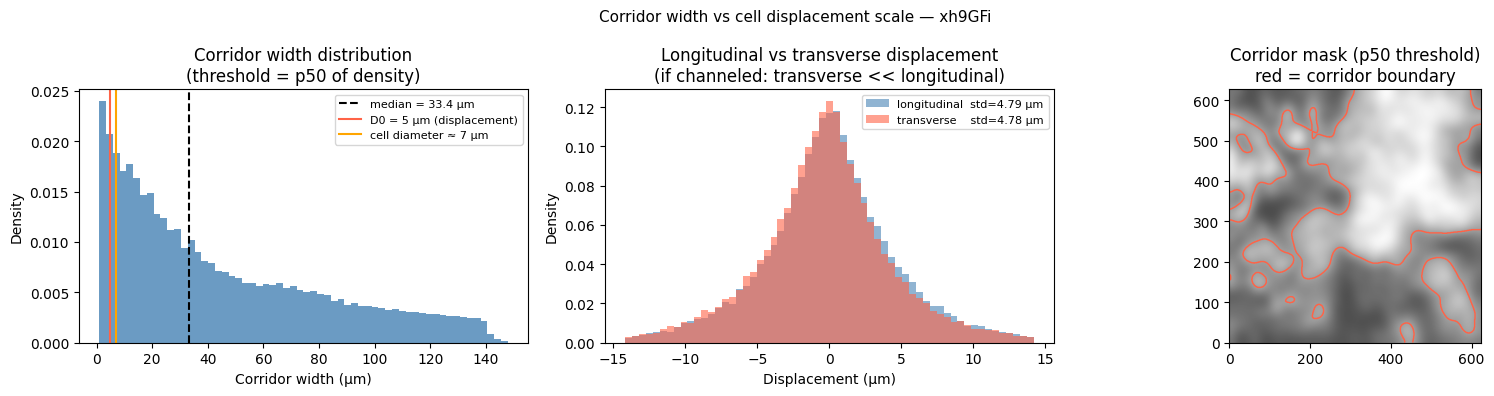

=== Corridor width vs tracking scale ===
  Median corridor width:      33.4 µm
  Cell diameter:              ~7 µm
  Per-frame displacement D0:  5.0 µm
  Width / D0 ratio:           6.7x

=== Displacement anisotropy ===
  Longitudinal std:  4.79 µm
  Transverse std:    4.78 µm
  Ratio (tran/long): 0.997  (1.0 = isotropic, <0.7 = channeled)

  MARGINAL: corridors are 33 µm, D0=5 µm (6.7x).
  Weak channeling — check quiver plot and transverse ratio before implementing.


In [33]:
# §10e — corridor width relative to cell displacement
# ─────────────────────────────────────────────────────────────────────────────
# If corridors are much wider than per-frame displacement, they don't
# constrain individual assignments — highway prior is too coarse.
#
# Approach:
#   1. Threshold density map → binary corridor mask
#   2. Measure cross-sectional width via distance transform
#   3. Compare to: cell diameter (~7 µm), displacement D0=5 µm/frame
#   4. Also measure transverse vs longitudinal displacement variance
#      (do cells actually stay within corridors between frames?)

from scipy.ndimage import distance_transform_edt, gaussian_filter, label as nd_label
from scipy.spatial import cKDTree
from skimage.measure import regionprops_table

uid_cw   = uIDs[0]
pr_cw    = pix_res[uid_cw]

# ── 1. Corridor width from distance transform ─────────────────────────────────
# Use the smoothed density map; threshold at 50th percentile to define corridors
thresh_pct = 50
thresh_val = float(np.percentile(dens_sm, thresh_pct))
corridor_mask = dens_sm >= thresh_val   # True = corridor

# Distance transform: for each corridor pixel, distance to nearest non-corridor
# This gives the local half-width of the corridor at each point
dist_transform = distance_transform_edt(corridor_mask) * pr_cw['y']   # µm
# Full width = 2 × half-width (distance transform gives radius)
corridor_widths = dist_transform[corridor_mask] * 2.0   # µm

# ── 2. Transverse vs longitudinal displacement ────────────────────────────────
# Corridor direction at each position = perpendicular to density gradient
# Compute gradient of smoothed density map
gy_grad, gx_grad = np.gradient(dens_sm)   # gradient in pixel units
grad_mag = np.sqrt(gy_grad**2 + gx_grad**2) + 1e-8
# Corridor direction (perpendicular to gradient):
#   gradient points across corridor → rotate 90° to get along-corridor direction
corr_dy = -gx_grad / grad_mag   # along-corridor y component
corr_dx =  gy_grad / grad_mag   # along-corridor x component

tracks_cw = tracks_coastal_c_per_uid[uid_cw]
long_disps = []   # displacement parallel to corridor direction
tran_disps = []   # displacement perpendicular (transverse)

for tid, tpoints in tracks_cw.items():
    ts = sorted(tpoints.keys())
    for i in range(len(ts) - 1):
        t0, t1 = ts[i], ts[i+1]
        if t1 - t0 != 1:
            continue
        p0 = tpoints[t0]   # [z, y, x] µm
        p1 = tpoints[t1]
        dy = float(p1[1] - p0[1])   # µm
        dx = float(p1[2] - p0[2])
        # grid lookup for corridor direction at p0
        py = int(np.clip(round(p0[1] / pr_cw['y']), 0, dens_sm.shape[0]-1))
        px = int(np.clip(round(p0[2] / pr_cw['x']), 0, dens_sm.shape[1]-1))
        cd_y = float(corr_dy[py, px])
        cd_x = float(corr_dx[py, px])
        # parallel (longitudinal) component
        long_disps.append(dy * cd_y + dx * cd_x)
        # perpendicular (transverse) component
        tran_disps.append(-dy * cd_x + dx * cd_y)

long_disps = np.array(long_disps)
tran_disps = np.array(tran_disps)

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle(f'Corridor width vs cell displacement scale — {uid_cw}', fontsize=11)

# Corridor width distribution
ax = axes[0]
ax.hist(corridor_widths, bins=60, color='steelblue', alpha=0.8, density=True)
ax.axvline(np.median(corridor_widths), color='k', ls='--', lw=1.5,
           label=f'median = {np.median(corridor_widths):.1f} µm')
ax.axvline(5.0, color='tomato', ls='-', lw=1.5, label='D0 = 5 µm (displacement)')
ax.axvline(7.0, color='orange', ls='-', lw=1.5, label='cell diameter ≈ 7 µm')
ax.set_xlabel('Corridor width (µm)')
ax.set_ylabel('Density')
ax.set_title(f'Corridor width distribution\n(threshold = p{thresh_pct} of density)')
ax.legend(fontsize=8)

# Transverse vs longitudinal displacement
ax2 = axes[1]
lim = float(np.percentile(np.abs(np.concatenate([long_disps, tran_disps])), 99))
bins2 = np.linspace(-lim, lim, 60)
ax2.hist(long_disps, bins=bins2, alpha=0.6, color='steelblue', density=True,
         label=f'longitudinal  std={np.std(long_disps):.2f} µm')
ax2.hist(tran_disps, bins=bins2, alpha=0.6, color='tomato',    density=True,
         label=f'transverse    std={np.std(tran_disps):.2f} µm')
ax2.set_xlabel('Displacement (µm)')
ax2.set_ylabel('Density')
ax2.set_title('Longitudinal vs transverse displacement\n(if channeled: transverse << longitudinal)')
ax2.legend(fontsize=8)

# Corridor mask overlaid on density
ax3 = axes[2]
ax3.imshow(dens_sm, cmap='gray', origin='lower', alpha=0.7)
ax3.contour(corridor_mask, levels=[0.5], colors='tomato', linewidths=1)
ax3.set_title(f'Corridor mask (p{thresh_pct} threshold)\nred = corridor boundary')

plt.tight_layout()
plt.show()

# ── Summary ───────────────────────────────────────────────────────────────────
med_width  = float(np.median(corridor_widths))
std_long   = float(np.std(long_disps))
std_tran   = float(np.std(tran_disps))
chan_ratio  = std_tran / std_long   # <1 = channeled, ≈1 = isotropic

print('=== Corridor width vs tracking scale ===')
print(f'  Median corridor width:      {med_width:.1f} µm')
print(f'  Cell diameter:              ~7 µm')
print(f'  Per-frame displacement D0:  5.0 µm')
print(f'  Width / D0 ratio:           {med_width/5.0:.1f}x')
print()
print('=== Displacement anisotropy ===')
print(f'  Longitudinal std:  {std_long:.2f} µm')
print(f'  Transverse std:    {std_tran:.2f} µm')
print(f'  Ratio (tran/long): {chan_ratio:.3f}  (1.0 = isotropic, <0.7 = channeled)')
print()
if chan_ratio < 0.7 and med_width < 20.0:
    print('  CHANNELED: corridors are narrow and displacements are anisotropic.')
    print('  → Transverse constraint is a real tracking prior. Implement §10f.')
elif med_width > 40.0:
    print(f'  TOO WIDE: corridors are {med_width:.0f} µm — {med_width/5.0:.0f}x the per-frame displacement.')
    print('  A cell can cross a full corridor width in one frame. No useful constraint.')
    print('  → Highway approach is not viable at this frame rate.')
    print(f'  At 10s/frame (D0=1.7 µm): width/D0={med_width/1.67:.0f}x — even worse.')
else:
    print(f'  MARGINAL: corridors are {med_width:.0f} µm, D0=5 µm ({med_width/5.0:.1f}x).')
    print('  Weak channeling — check quiver plot and transverse ratio before implementing.')
